In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Data investigation

In [2]:
data = pd.read_csv("../data/nova_pay_combined.csv", parse_dates=["timestamp"])

In [3]:
data['is_fraud'].value_counts(dropna=False)

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [4]:
data['is_fraud'].value_counts(normalize=True, dropna=False) * 100

is_fraud
0    91.254386
1     8.745614
Name: proportion, dtype: float64

The raw dataset contained 10,403 legitimate transactions and 997 fraudulent transactions. Fraud represented approximately 8.75% of all transactions, confirming that the target variable was imbalanced.

In [5]:
data

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,1.351351,5c06f00d-a089-402b-9b14-e7bc7ae56ed2,False,221.126.239.197,US,False,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,822.222222,dafd943c-f12f-48b9-83df-401efaad0fe3,False,26.6.123.44,UK,True,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,61.666667,94475656-37f3-4b9c-b3cd-6d89416866ac,True,184.150.56.237,US,True,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,0eab90ef-4273-4239-8b51-2c96b2a24756,False,31.125.175.93,US,False,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [7]:
data.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [8]:
data.shape

(11400, 26)

In [9]:
data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [10]:
data.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

Data cleaning

In [11]:
data.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [12]:
(data.isnull().sum() / len(data)) * 100

transaction_id               0.000000
customer_id                  0.000000
timestamp                    0.254386
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
channel                      0.000000
amount_src                   0.000000
amount_usd                   2.675439
fee                          2.587719
exchange_rate_src_to_dest    0.000000
device_id                    0.000000
new_device                   0.000000
ip_address                   2.675439
ip_country                   2.640351
location_mismatch            0.000000
ip_risk_score                0.000000
kyc_tier                     2.631579
account_age_days             0.000000
device_trust_score           2.587719
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float

Handling duplicate records

In [13]:
# Count duplicate rows

data.duplicated().sum()

np.int64(200)

In [14]:
# Remove exact duplicate rows

data = data.drop_duplicates().reset_index(drop=True)

In [15]:
# Verify duplicate removal

data.duplicated().sum()

np.int64(0)

The original dataset contained 200 exact duplicate rows. These records were removed to prevent repeated observations from distorting the analysis and model training. After removal, the dataset contained 11,200 unique records, and a final check confirmed that no duplicate rows remained.

 Missing values were identified in timestamp, transaction amount, transaction fee, IP-related information, KYC tier, and device trust score.

### Handling missing value

In [16]:
# Remove thousands separators and convert amount_src to numeric
data['amount_src'] = pd.to_numeric(
    data['amount_src']
        .astype(str)
        .str.replace(',', '', regex=False),
    errors='coerce'
)

In [17]:
# Verify the converted data type and missing values
data['amount_src'].dtype, data['amount_src'].isna().sum()

(dtype('float64'), np.int64(0))

In [18]:
# Counts negative souce transaction amounts

(data['amount_src'] < 0).sum()

np.int64(100)

In [19]:
# Inspect transactions with negative source amounts

data[data['amount_src'] < 0][
    ['amount_src', 'amount_usd', 'source_currency',
     'dest_currency', 'channel', 'is_fraud']
].head()

,amount_src,amount_usd,source_currency,dest_currency,channel,is_fraud
328,-37.08,37.08,USD,NGN,mobile,0
564,-176.92,176.92,USD,USD,WEB,0
576,-702.71,702.71,USD,CAD,mobile,0
596,-230.36,230.36,USD,GBP,mobile,0
602,-203.83,150.83,CAD,CAD,web,0


In [20]:
# Check fraud distribution

data[data['amount_src'] < 0]['is_fraud'].value_counts()

is_fraud
0    96
1     4
Name: count, dtype: int64

In [21]:
# Calculate fraud rate among negative source amounts

data[data['amount_src'] < 0]['is_fraud'].mean() * 100

np.float64(4.0)

In [22]:
# Overall fraud rate

data['is_fraud'].value_counts(normalize=True) * 100


is_fraud
0    91.116071
1     8.883929
Name: proportion, dtype: float64

During data validation, 100 transactions with negative amount_src values were identified. Of these, 4 were fraudulent, giving a fraud rate of 4.0. 

This was lower than the overall dataset fraud rate of 8.88%, suggesting that negative transaction amounts were not strongly associated with fraud in this dataset. 

The values were therefore retained, as they may represent legitimate refunds, reversals, or transaction adjustments.

In [23]:
data['source_currency'].value_counts()

source_currency
USD    7875
GBP    2111
CAD    1214
Name: count, dtype: int64

In [24]:
# Select complete records with positive source amounts

valid_rate_rows = data[
    data['amount_usd'].notna() &
    data['amount_src'].notna() &
    (data['amount_src'] > 0)
]

In [25]:
# Calculate average conversion rates by source currency

rates = round(
    (
        valid_rate_rows['amount_usd'] /
        valid_rate_rows['amount_src']
    )
    .groupby(valid_rate_rows['source_currency'])
    .mean(),
    1
)

rates

source_currency
CAD    0.7
GBP    1.2
USD    1.0
dtype: float64

In [26]:
# Identify rows with missing USD amounts

missing_usd = data['amount_usd'].isna()

In [27]:
# Estimate missing USD amounts using currency-specific rates

data.loc[missing_usd, 'amount_usd'] = (
    data.loc[missing_usd, 'amount_src'].abs()
    * data.loc[missing_usd, 'source_currency'].map(rates)
)

Using .abs() avoids creating a negative USD amount for a transaction whose source amount has a negative sign.

In [28]:
# Confirm that all missing USD amounts were filled

data['amount_usd'].isna().sum()

np.int64(0)

In [29]:
# Inspect reconstructed USD amounts

data.loc[
    missing_usd,
    ['amount_src', 'amount_usd', 'source_currency']
].head()

,amount_src,amount_usd,source_currency
13,322.24,386.688,GBP
49,255.06,255.060,USD
151,502.97,502.970,USD
163,100.87,70.609,CAD
168,265.30,265.300,USD


Missing values in amount_usd were estimated using the relationship between the original transaction amount and its source currency. 

Currency-specific conversion rates were calculated from complete records with positive source amounts, preventing negative transaction adjustments from distorting the estimated rates. 

The resulting rates were then applied to the absolute source amounts of transactions with missing USD values. 

This method preserved the relationship between transaction value and currency rather than applying a general mean or median imputation.

In [30]:
data.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [31]:
# Fill numerical missing values with the median

data['fee']= data['fee'].fillna(data['fee'].median())
data['device_trust_score']= data['device_trust_score'].fillna(data['device_trust_score'].median())

Missing numerical values in fee, and device_trust_score were filled using their median values.

The median was selected because it is less sensitive to extreme transaction values than the mean.

In [32]:
data['fee'].describe()

count    11200.000000
mean        96.733744
std        940.236004
min         -1.000000
25%          2.410000
50%          3.500000
75%          5.470000
max       9999.990000
Name: fee, dtype: float64

In [33]:
# Replace the special-coded values

data['fee']= np.where(data['fee']==-1.000000, data['fee'].median(), data['fee'])
data['fee']= np.where(data['fee']==9999.990000, data['fee'].median(), data['fee'])

In [34]:
# Verify

data['fee'].describe()

count    11200.000000
mean         7.519547
std         20.262598
min          0.500000
25%          2.450000
50%          3.500000
75%          5.350000
max        179.740000
Name: fee, dtype: float64

Missing values in fee are imputed using median values. 

The median was selected because it is robust to extreme values and skewed distributions, making it more suitable than the mean for transaction-related variables.

### Standardized Categorical Columns

In [35]:
categorical_cols = [
    'home_country',
    'source_currency',
    'dest_currency',
    'channel',
    'ip_country',
    'kyc_tier'
]

for col in categorical_cols:
    print(f'\n{col}')
    print(data[col].value_counts(dropna=False))
    print('-' * 50)


home_country
home_country
US         7784
UK         2091
CA         1205
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64
--------------------------------------------------

source_currency
source_currency
USD    7875
GBP    2111
CAD    1214
Name: count, dtype: int64
--------------------------------------------------

dest_currency
dest_currency
NGN    1447
INR    1304
USD    1302
CNY    1297
PHP    1290
GBP    1273
CAD    1260
EUR    1177
MXN     850
Name: count, dtype: int64
--------------------------------------------------

channel
channel
mobile       6242
web          3674
ATM           989
mobille        59
 mobile        48
MOBILE         46
unknown        37
WEB            35
 web           33
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64
--------------------------------------------------

ip_country
ip_country
US         6713
UK         2372
CA         1703
NaN         296
 US          48
unknown    

In [36]:
# Channel

data['channel'] = (
    data['channel']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'web': 'Web',
        'weeb': 'Web',
        'mobile': 'Mobile',
        'mobille': 'Mobile',
        'atm': 'ATM',
        'unknown': 'Unknown',
        'nan': 'Unknown'
    })
)

In [37]:
# Home Country 

data['home_country'] = (
    data['home_country']
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        'UNKNOWN': 'Unknown'
    })
)

In [38]:
# IP Country

data['ip_country'] = (
    data['ip_country']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        'UNKNOWN': 'Unknown',
        'NAN': 'Unknown'
    })
)

In [39]:
# KYC Tier

data['kyc_tier'] = (
    data['kyc_tier']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'standrd': 'Standard',
        'enhancd': 'Enhanced',
        'unknown': 'Unknown',
        'nan': 'Unknown',
        'standard': 'Standard',
        'enhanced': 'Enhanced',
        'low': 'Low'
    })
)

In [40]:
for col in ['channel', 'home_country', 'ip_country', 'kyc_tier']:
    print(f'\n{col}')
    print(data[col].value_counts(dropna=False))
    print('-' * 50)


channel
channel
Mobile     6395
Web        3766
ATM        1002
Unknown      37
Name: count, dtype: int64
--------------------------------------------------

home_country
home_country
US         7852
UK         2104
CA         1212
Unknown      32
Name: count, dtype: int64
--------------------------------------------------

ip_country
ip_country
US         6761
UK         2390
CA         1718
Unknown     331
Name: count, dtype: int64
--------------------------------------------------

kyc_tier
kyc_tier
Standard    7985
Enhanced    1839
Low         1047
Unknown      329
Name: count, dtype: int64
--------------------------------------------------


Categorical variables were standardized to ensure consistent category labels. Variations in capitalization, whitespace, and placeholder values (e.g., 'unknown', 'UNKNOWN', 'NaN') were unified into a single representation ('Unknown').

This standardization improved data consistency and prepared the dataset for subsequent missing value imputation and analysis.

Investigate home country

In [41]:
data['home_country'].value_counts(dropna=False)

home_country
US         7852
UK         2104
CA         1212
Unknown      32
Name: count, dtype: int64

In [42]:
data['home_country'].isna().sum()

np.int64(0)

In [43]:
# Investigate home country distribution by IP country

pd.crosstab(data['ip_country'], data['home_country'])

home_country,CA,UK,US,Unknown
ip_country,,,,
CA,948,179,586,5
UK,118,1679,588,5
US,121,175,6446,19
Unknown,25,71,232,3


In [44]:
# Determine the most common home country within each IP country

home_by_ip = (
    data.loc[data['home_country'] != 'Unknown']
    .groupby('ip_country')['home_country']
    .agg(lambda x: x.mode().iloc[0])
)

home_by_ip

ip_country
CA         CA
UK         UK
US         US
Unknown    US
Name: home_country, dtype: str

In [45]:
# Identify records with unknown home country

missing_home = data['home_country'] == 'Unknown'

In [46]:
# Verify all unknown values can be estimated

estimated_home = (
    data.loc[missing_home, 'ip_country']
    .map(home_by_ip)
)

estimated_home.isna().sum()

np.int64(0)

In [47]:
# Impute unknown home countries

data.loc[missing_home, 'home_country'] = estimated_home

In [48]:
# Verify the imputation

data['home_country'].value_counts(dropna=False)

home_country
US    7874
UK    2109
CA    1217
Name: count, dtype: int64

The relationship between IP country and home country was examined using a cross-tabulation. 

Since each IP country was most frequently associated with the corresponding home country, unknown home-country values were imputed using the most common home country within each IP-country group.

 All unknown values were successfully replaced, preserving the existing geographical relationship within the dataset.

Investigate relationship between IP country and home country

In [49]:
# Investigate IP country patterns within each home country

pd.crosstab(
    data['home_country'],
    data['ip_country'],
    margins=True
)

ip_country,CA,UK,US,Unknown,All
home_country,,,,,
CA,953,118,121,25,1217
UK,179,1684,175,71,2109
US,586,588,6465,235,7874
All,1718,2390,6761,331,11200


In [50]:
# Calculate the most common IP country within each home country

ip_country_by_home = (
    data.loc[data['ip_country'] != 'Unknown']
    .groupby('home_country')['ip_country']
    .agg(lambda x: x.mode().iloc[0])
)

ip_country_by_home

home_country
CA    CA
UK    UK
US    US
Name: ip_country, dtype: str

In [51]:
# Identify rows with unknown IP country

missing_ip_country = data['ip_country'] == 'Unknown'

In [52]:
# Estimate IP country using the home-country group mode

estimated_ip = (
    data.loc[missing_ip_country, 'home_country']
    .map(ip_country_by_home)
)

In [53]:
# Check whether any estimated values are still missing

estimated_ip.isna().sum()

np.int64(0)

In [54]:
# Impute unknown IP countries using the group mode

data.loc[missing_ip_country, 'ip_country'] = estimated_ip

In [55]:
# Verify the imputation

data['ip_country'].value_counts(dropna=False)

ip_country
US    6996
UK    2461
CA    1743
Name: count, dtype: int64

The relationship between home_country and ip_country was examined before imputation.

For each home-country group, the most frequently occurring IP country was calculated and used to replace unknown IP-country values.
 
All 329 unknown values were successfully estimated, and no unresolved IP-country values remained.

Investigate KYC_tier

In [56]:
# Investigate KYC tier patterns within each home country

pd.crosstab(
    data['home_country'],
    data['kyc_tier'],
    margins=True
)

kyc_tier,Enhanced,Low,Standard,Unknown,All
home_country,,,,,
CA,32,434,727,24,1217
UK,38,182,1816,73,2109
US,1769,431,5442,232,7874
All,1839,1047,7985,329,11200


In [57]:
# Calculate the most common KYC tier within each home country

kyc_by_home = (
    data.loc[data['kyc_tier'] != 'Unknown']
    .groupby('home_country')['kyc_tier']
    .agg(lambda x: x.mode().iloc[0])
)

kyc_by_home

home_country
CA    Standard
UK    Standard
US    Standard
Name: kyc_tier, dtype: str

In [58]:
# Identify rows with unknown KYC tier

missing_kyc = data['kyc_tier'] == 'Unknown'

In [59]:
# Estimate replacement values

estimated_kyc = (
    data.loc[missing_kyc, 'home_country']
    .map(kyc_by_home)
)

In [60]:
# Verify that all unknown values can be estimated

estimated_kyc.isna().sum()

np.int64(0)

In [61]:
# Impute unknown KYC tiers 

data.loc[missing_kyc, 'kyc_tier'] = estimated_kyc

In [62]:
# Verify the imputation

data['kyc_tier'].value_counts(dropna=False)

kyc_tier
Standard    8314
Enhanced    1839
Low         1047
Name: count, dtype: int64

The relationship between home_country and kyc_tier was examined before imputation. 

The most common KYC tier within each home-country group was identified and used to replace records labeled as Unknown. 

All unknown KYC tier values were successfully estimated, leaving no unresolved categories while preserving the existing relationship between customer location and verification level.

Investigate Transaction channel

In [63]:
pd.crosstab(data['new_device'], data['channel'])

channel,ATM,Mobile,Unknown,Web
new_device,,,,
False,885,5746,35,3198
True,117,649,2,568


In [64]:
pd.crosstab(data['location_mismatch'], data['channel'])

channel,ATM,Mobile,Unknown,Web
location_mismatch,,,,
False,838,5483,32,3022
True,164,912,5,744


In [65]:
pd.crosstab(data['home_country'], data['channel'])

channel,ATM,Mobile,Unknown,Web
home_country,,,,
CA,107,661,6,443
UK,185,1206,8,710
US,710,4528,23,2613


The relationship between transaction channel and new device status, location mismatch, and home country was examined. 


Across all groups, Mobile remained the most frequent transaction channel, indicating that no subgroup exhibited a distinct dominant pattern.

Therefore, group-based imputation was unlikely to provide additional benefit, and the missing transaction channel values were imputed using the overall mode (Mobile).

#### Mode imputation for Transaction channel

In [66]:
# Identify records with unknown transaction channel

missing_channel = data['channel'] == 'Unknown'

In [67]:
# Determine the most common transaction channel

channel_mode = (
    data.loc[data['channel'] != 'Unknown', 'channel']
    .mode()
    .iloc[0]
)

channel_mode

'Mobile'

In [68]:
# Impute unknown transaction channels using the overall mode

data.loc[missing_channel, 'channel'] = channel_mode

In [69]:
# Verify the imputation

data['channel'].value_counts(dropna=False)

channel
Mobile    6432
Web       3766
ATM       1002
Name: count, dtype: int64

All unknown transaction channel values were successfully imputed using the overall mode (Mobile). 

Verification confirmed that no unknown values remained after imputation.

### Timestamp Data Preparation

In [70]:
data['timestamp'].value_counts()

timestamp
0000-00-00T00:00:00Z                21
2025/13/40 25:61:00                 10
2024-01-22 00:24:24.468549+00:00     2
2022-10-03 18:40:59.468549+00:00     1
2022-10-03 20:39:38.468549+00:00     1
                                    ..
2025-11-25 10:05:35.573611+00:00     1
2025-11-26 07:09:56.573611+00:00     1
2025-11-27 06:19:11.573611+00:00     1
2025-11-28 00:53:28.573611+00:00     1
2025-11-29 20:10:47.573611+00:00     1
Name: count, Length: 11141, dtype: int64

In [71]:
# Convert the column to datetime format

data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

In [72]:
data.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,Standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,Web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,Standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,Mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,Enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,Mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,Standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,Mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,Enhanced,257,0.894,0,0.257,0,0,0.0,0


In [73]:
# Extract date and time features

data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['day_of_month'] = data['timestamp'].dt.day
data['day_of_week'] = data['timestamp'].dt.day_name()
data['hour'] = data['timestamp'].dt.hour

In [74]:
# Get weekday number: Monday = 0, Sunday = 6

day_number = data['timestamp'].dt.dayofweek

In [75]:
# Create weekend indicator

data['is_weekend'] = day_number.isin([5, 6]).astype('Int64')

In [76]:
# Keep missing timestamps as missing, not as weekdays

data.loc[day_number.isna(), 'is_weekend'] = pd.NA

The timestamp column was converted into datetime format. Useful time-related features such as year, month, day of the week, hour, and weekend status were extracted before removing the original timestamp column.

In [77]:
# Create an indicator for missing IP addresses

data['ip_address_missing'] = data['ip_address'].isna().astype(int)

A missing-value indicator was created for the IP address column

In [78]:
# Drop identifier and redundant columns

data.drop(columns=['ip_address','transaction_id', 'customer_id', 'device_id'], inplace=True)

Transaction ID, customer ID, device ID, raw IP address, and the original timestamp were excluded because they function mainly as identifiers or had already been transformed into more useful features.

In [79]:
data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day_of_month,day_of_week,hour,is_weekend,ip_address_missing
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,US,False,0.123,Standard,263,0.522,0,0.223,0,0,0.0,0,2022.0,10.0,3.0,Monday,18.0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,Web,208.51,154.29,4.24,12.758621,True,CA,False,0.569,Standard,947,0.475,0,0.268,0,1,0.0,0,2022.0,10.0,3.0,Monday,20.0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,Mobile,160.33,160.33,2.70,7.142857,False,US,False,0.437,Enhanced,367,0.939,0,0.176,0,0,0.0,0,2022.0,10.0,3.0,Monday,23.0,0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,Mobile,59.41,59.41,2.22,0.925926,False,US,False,0.594,Standard,147,0.551,0,0.391,0,0,0.0,0,2022.0,10.0,4.0,Tuesday,1.0,0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,Mobile,200.96,200.96,3.61,83.333333,False,US,False,0.121,Enhanced,257,0.894,0,0.257,0,0,0.0,0,2022.0,10.0,4.0,Tuesday,9.0,0,0


In [80]:
data.shape

(11200, 29)

In [81]:
data['year'].value_counts()

year
2024.0    3938
2023.0    3354
2025.0    3067
2022.0     781
Name: count, dtype: int64

In [82]:
data.dtypes

timestamp                    datetime64[us, UTC]
home_country                                 str
source_currency                              str
dest_currency                                str
channel                                      str
amount_src                               float64
amount_usd                               float64
fee                                      float64
exchange_rate_src_to_dest                float64
new_device                                  bool
ip_country                                   str
location_mismatch                           bool
ip_risk_score                            float64
kyc_tier                                     str
account_age_days                           int64
device_trust_score                       float64
chargeback_history_count                   int64
risk_score_internal                      float64
txn_velocity_1h                            int64
txn_velocity_24h                           int64
corridor_risk       

In [83]:
data.duplicated().sum()

np.int64(0)

In [84]:
data = data.dropna()

In [85]:
data.isnull().sum()

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
year                         0
month                        0
day_of_month                 0
day_of_week                  0
hour                         0
is_weekend                   0
ip_address_missing           0
dtype: int64

Check for Outliers

In [86]:
numerical_columns= data.select_dtypes(include='number')

In [87]:
len(numerical_columns.columns)

19

In [88]:
continuous_columns = [
    'amount_src',
    'amount_usd',
    'fee',
    'exchange_rate_src_to_dest',
    'ip_risk_score',
    'account_age_days',
    'device_trust_score',
    'chargeback_history_count',
    'risk_score_internal',
    'txn_velocity_1h',
    'txn_velocity_24h',
    'corridor_risk'
]

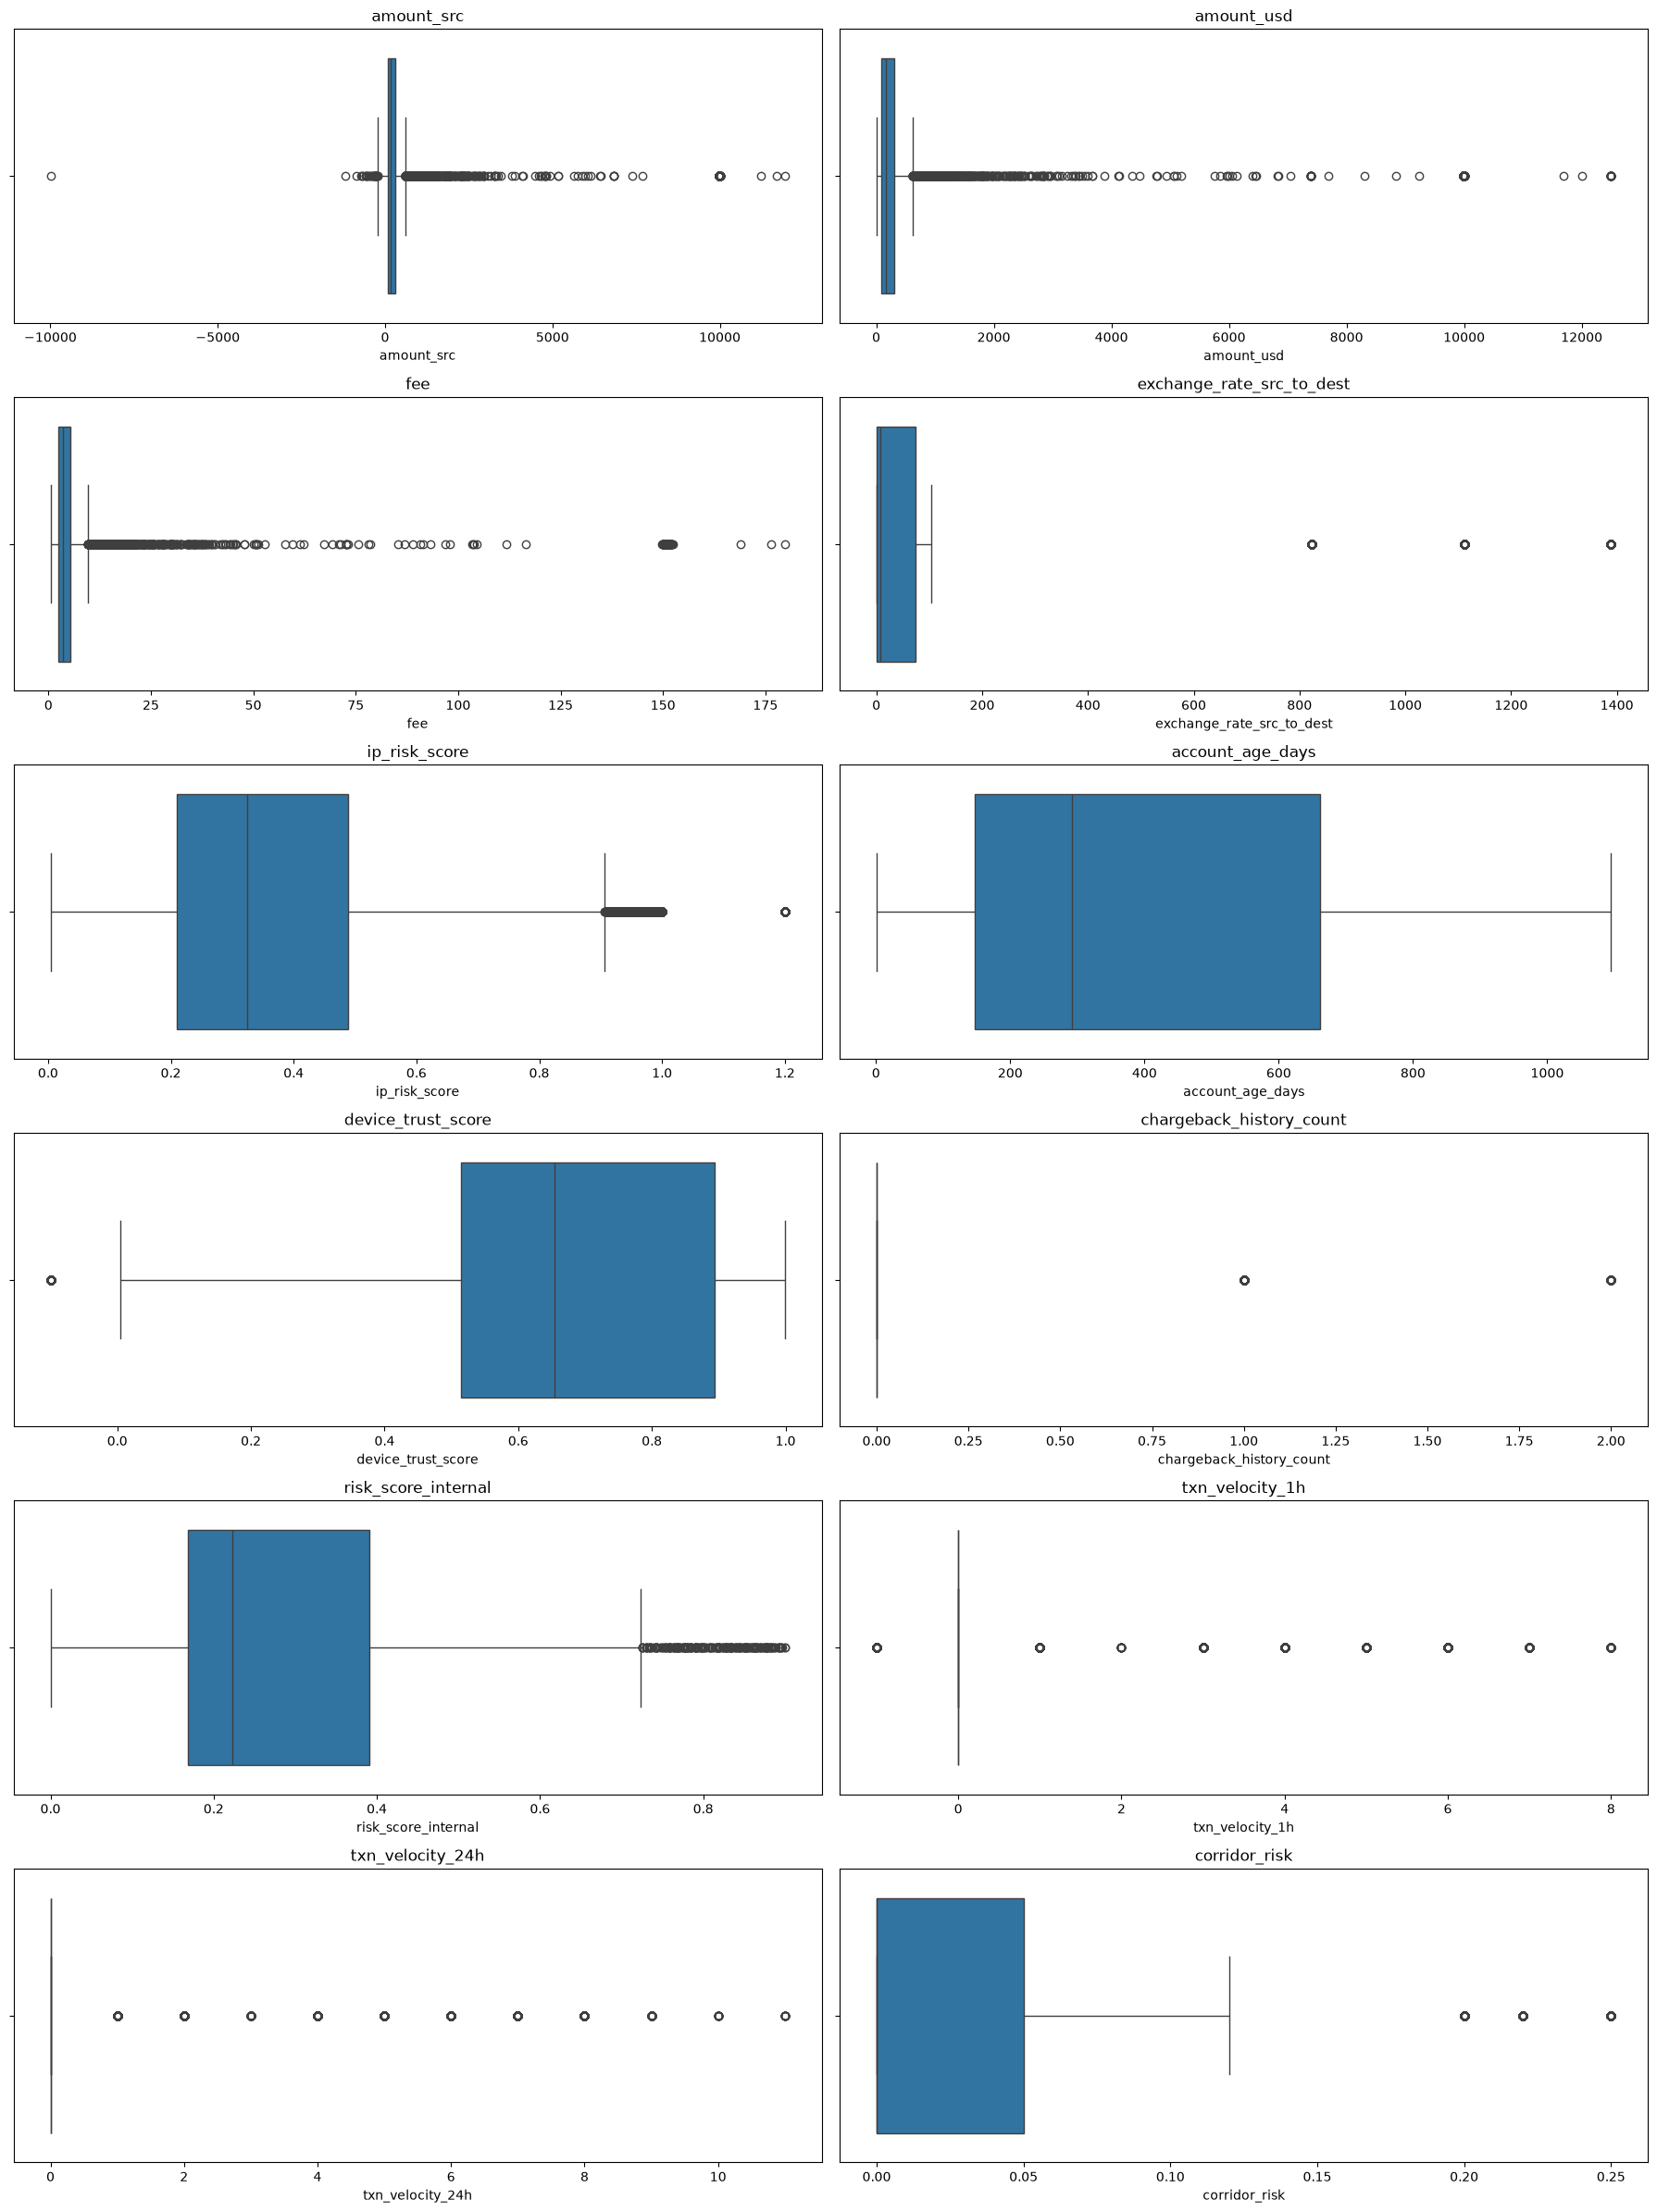

In [89]:
fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(18, 24))
ax = ax.flatten()

for index, column_name in enumerate(continuous_columns):
    sns.boxplot(x=data[column_name], ax=ax[index])
    ax[index].set_title(column_name)

plt.tight_layout()
plt.show()

Boxplots were used to examine the distribution of the numerical variables and identify potential outliers.

Several variables, including amount_usd, fee, exchange_rate_src_to_dest, txn_velocity_1h, and txn_velocity_24h, exhibited extreme values beyond the whiskers of the boxplots. 

Such observations are expected in financial transaction data and may represent unusual or high-risk transactions rather than data entry errors. Therefore, no outliers were removed at this stage, as they may contain valuable information for fraud detection.

Investigating Special Coded Values

In [90]:
# Check the distribution of one-hour transaction velocity values

data['txn_velocity_1h'].value_counts().sort_index()

txn_velocity_1h
-1     200
 0    9727
 1     132
 2      18
 3     262
 4     242
 5     189
 6     169
 7     113
 8      88
Name: count, dtype: int64

In [91]:
# Count records with the unexpected velocity value of -1

(data['txn_velocity_1h'] == -1).sum()

np.int64(200)

In [92]:
# Count records with the unexpected device trust score of -0.1

(data['device_trust_score'] == -0.1).sum()

np.int64(200)

In [93]:
# Inspect records containing the special coded velocity value

data[data['txn_velocity_1h'] == -1].head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day_of_month,day_of_week,hour,is_weekend,ip_address_missing
51,2022-10-09 08:57:10.468549+00:00,US,USD,EUR,Web,67.19,67.19,3.5,0.925926,False,CA,True,1.2,Standard,263,-0.1,0,0.223,-1,0,0.00,0,2022.0,10.0,9.0,Sunday,8.0,1,0
60,2022-10-10 12:06:38.468549+00:00,US,USD,USD,Mobile,190.42,190.42,3.5,1.000000,False,US,False,1.2,Standard,298,-0.1,0,0.166,-1,0,0.00,0,2022.0,10.0,10.0,Monday,12.0,0,0
78,2022-10-12 08:33:52.468549+00:00,US,USD,INR,Web,130.13,130.13,3.5,83.333333,False,US,False,1.2,Enhanced,257,-0.1,0,0.257,-1,0,0.00,0,2022.0,10.0,12.0,Wednesday,8.0,0,0
225,2022-10-28 19:29:13.468549+00:00,US,USD,GBP,ATM,81.19,81.19,3.5,0.800000,False,US,False,1.2,Standard,147,-0.1,0,0.391,-1,1,0.00,0,2022.0,10.0,28.0,Friday,19.0,0,0
328,2022-11-10 03:14:05.468549+00:00,US,USD,NGN,Mobile,-37.08,37.08,3.5,1111.111111,False,US,False,1.2,Standard,298,-0.1,0,0.166,-1,0,0.25,0,2022.0,11.0,10.0,Thursday,3.0,0,0


In [94]:
# Check whether both special coded values occur in the same records

(
    (data['txn_velocity_1h'] == -1) &
    (data['device_trust_score'] == -0.1)
).sum()

np.int64(200)

During data validation, the txn_velocity_1h feature contained 200 records with a value of -1, while the device_trust_score feature contained 200 records with a value of -0.1.

Further verification confirmed that these values occurred in the same records, indicating that they are likely linked special coded values rather than valid negative measurements. 

Since the dataset documentation did not define their meaning, the records were retained and documented for transparency to avoid making unsupported assumptions during data cleaning.

Exploratory Data Analysis

In [95]:
# Target column

In [96]:
data['is_fraud'].value_counts()

is_fraud
0    10147
1      993
Name: count, dtype: int64

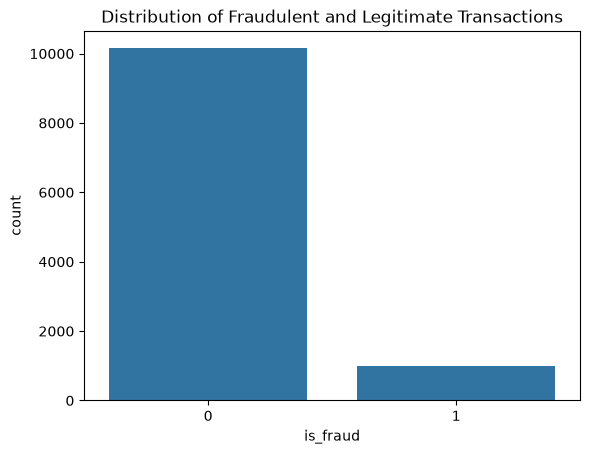

is_fraud
0    91.086176
1     8.913824
Name: proportion, dtype: float64

In [97]:
# What proportion of transactions are fraudulent?

sns.countplot(data=data, x='is_fraud')
plt.title('Distribution of Fraudulent and Legitimate Transactions')
plt.show();

data['is_fraud'].value_counts(normalize=True) * 100

Most transactions are legitimate, while fraudulent transactions represent a much smaller proportion of the dataset, indicating a class imbalance.

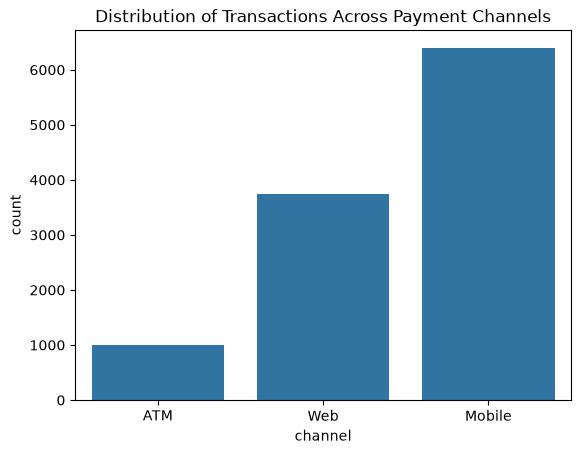

In [98]:
# How are transactions distributed across payment channels?

sns.countplot(data=data, x = 'channel')
plt.title('Distribution of Transactions Across Payment Channels')
plt.show();

Mobile is the most frequently used transaction channel, accounting for the largest share of transactions, followed by Web transactions, while ATM transactions represent the smallest proportion. A small number of transactions were recorded under the Unknown category due to unavailable channel information. This distribution suggests that customers primarily use digital channels to perform transactions, making them important areas for subsequent fraud analysis.

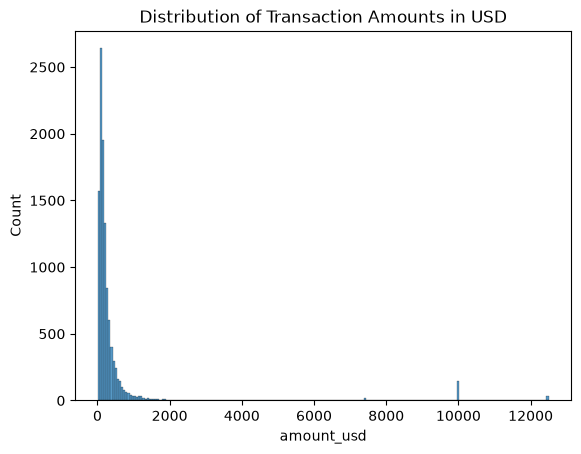

In [99]:
# What is the distribution of transaction amounts in USD?

sns.histplot(data=data, x='amount_usd')
plt.title('Distribution of Transaction Amounts in USD')
plt.show();


The distribution of transaction amounts in U.S. dollars is highly right-skewed, with most transactions concentrated at lower values and a long tail extending toward larger amounts.

A small number of high-value transactions are present, indicating potential outliers. While these transactions are uncommon, they may represent legitimate large transactions or potentially fraudulent activity and therefore warrant further investigation during the analysis.

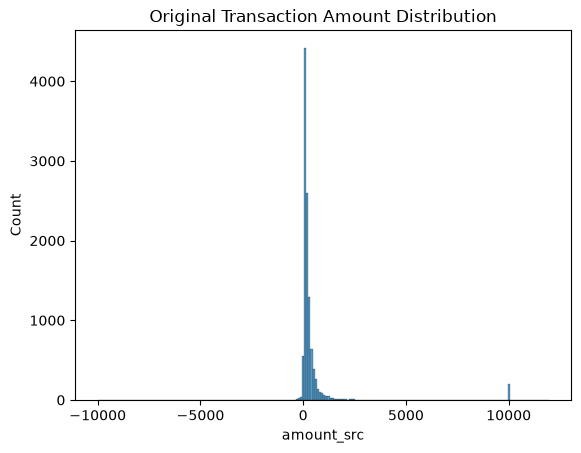

In [100]:
# How are original transaction amounts distributed across the dataset?

sns.histplot(data=data, x= 'amount_src')
plt.title('Original Transaction Amount Distribution')
plt.show();


The distribution of amount_src is highly right-skewed. Most transactions are concentrated at relatively low values, while a small number involve substantially larger amounts.

The distribution also extends below zero because the dataset contains some negative source amounts; these values were investigated during data cleaning and retained as potentially valid transaction adjustments. 

Overall, the chart shows that high-value transactions are uncommon compared with typical transaction amounts.

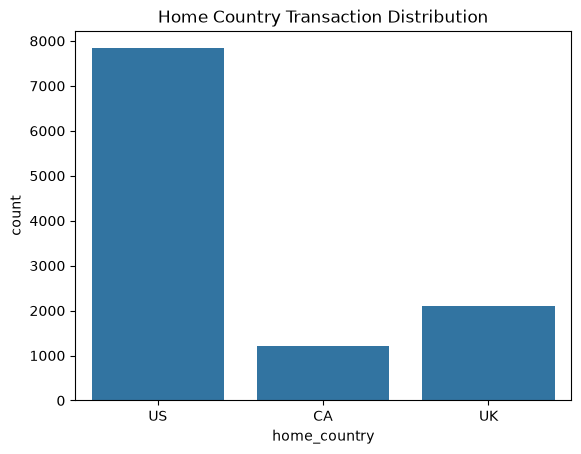

In [101]:
# Which home countries account for the highest transaction volume?

sns.countplot(data=data, x='home_country')
plt.title('Home Country Transaction Distribution')
plt.show();

The majority of transactions originate from the United States (US), followed by the United Kingdom (UK) and Canada (CA). 

This indicates that the dataset is dominated by US-based transactions, which should be considered when interpreting country-level patterns.

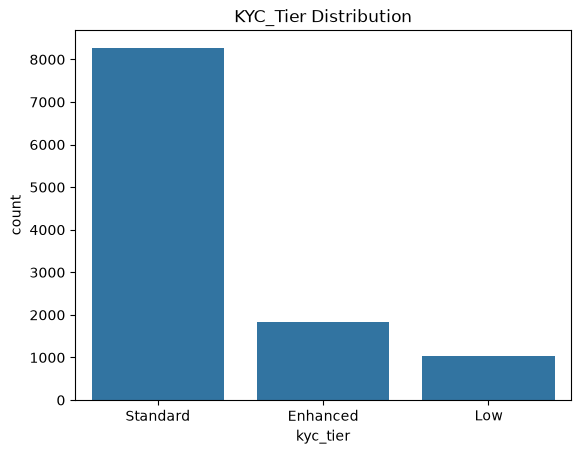

In [102]:
# How are transactions distributed across KYC verification tiers?

sns.countplot(data=data, x='kyc_tier')
plt.title('KYC_Tier Distribution')
plt.show();

The Standard KYC tier accounts for the majority of transactions, followed by Enhanced and Low verification levels. 

This suggests that most users have completed at least the standard level of identity verification.

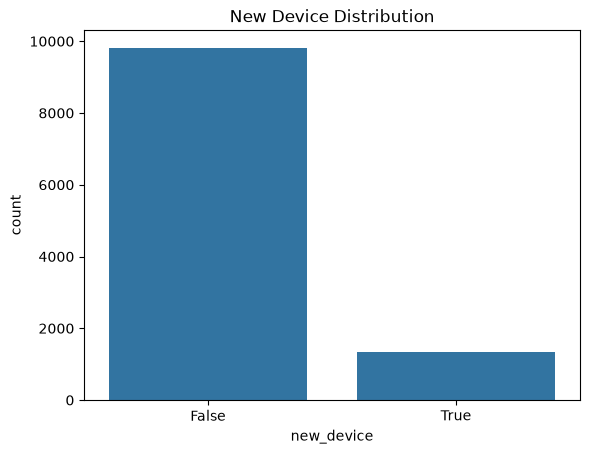

In [103]:
# What is the distribution of transactions by device status?

sns.countplot(data=data, x='new_device')
plt.title('New Device Distribution')
plt.show()

Most transactions were performed using previously recognized devices, while transactions from new devices represent a much smaller proportion of the dataset. 

This indicates that repeat device usage is common among customers, although new device activity may warrant further investigation during fraud analysis.

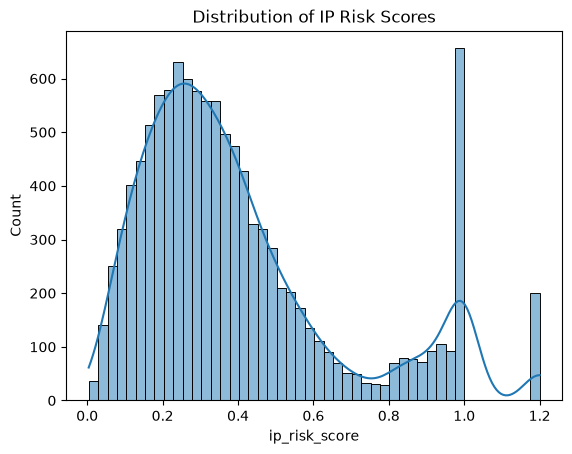

In [104]:
# How are IP risk scores distributed across transactions?

sns.histplot(data=data, x='ip_risk_score', kde=True)
plt.title('Distribution of IP Risk Scores')
plt.show();

In [105]:
data['ip_risk_score'].value_counts().head(10)

ip_risk_score
1.000    555
1.200    200
0.251     40
0.301     37
0.223     36
0.279     36
0.299     34
0.295     34
0.182     33
0.263     33
Name: count, dtype: int64

IP risk scores are concentrated in the lower-to-moderate range, with most transactions having scores between approximately 0.1 and 0.5.The frequency of transactions decreases as the risk score increases, indicating that higher-risk IP scores are less common.

However, noticeable peaks occur at 1.0 and 1.2, with 555 and 200 transactions respectively, suggesting that many transactions share these elevated risk scores.

These observations may warrant further investigation to determine whether higher IP risk scores are associated with fraudulent activity.

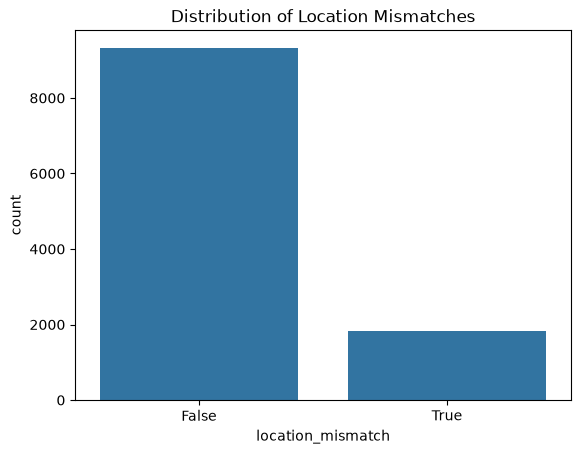

In [106]:
# How common are location mismatches across transactions?
sns.countplot(data=data, x='location_mismatch')
plt.title('Distribution of Location Mismatches')
plt.show();

Most transactions do not have a location mismatch, indicating that the transaction location generally matches the expected location for the customer. 

However, a smaller proportion of transactions are flagged with a location mismatch. Although less common, these transactions may require further investigation, as unexpected transaction locations can be associated with elevated fraud risk.

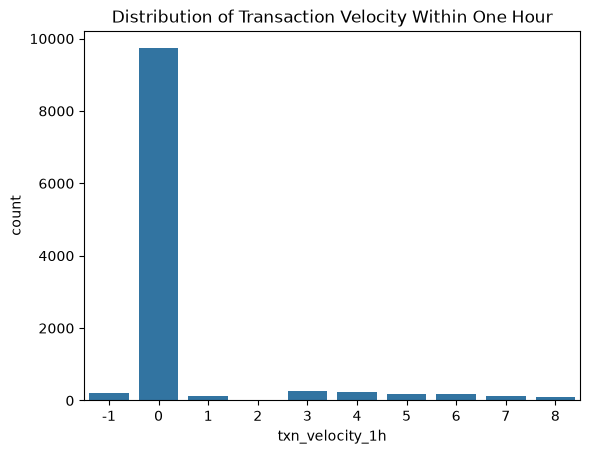

In [107]:
# What is the distribution of one-hour transaction velocity?
sns.countplot(data=data, x='txn_velocity_1h')
plt.title('Distribution of Transaction Velocity Within One Hour')
plt.show();

Most transactions recorded a one-hour transaction velocity of 0, indicating that repeated transaction activity within a short period was uncommon.

The number of transactions decreased as the velocity increased, with only a small proportion showing high-frequency activity within one hour. 

The chart also includes 200 records with a value of −1; these were investigated during data cleaning and found to occur alongside a device trust score of −0.1, suggesting linked special coded values rather than genuine negative measurements.

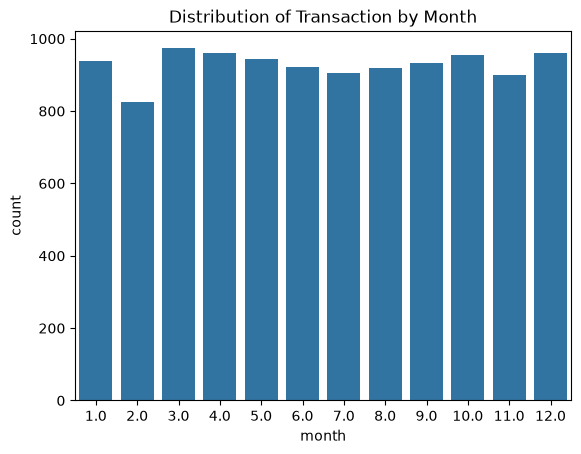

In [108]:
# How are transactions distributed across different months?

sns.countplot(data=data, x='month')
plt.title('Distribution of Transaction by Month')
plt.show();

Transaction activity is relatively consistent across all twelve months, with no significant seasonal spikes or declines. 

While a few months, such as March, April, and December, record slightly higher transaction counts, and February records the fewest, the differences are relatively small. 

This suggests that transactions occur steadily throughout the year rather than being concentrated in specific months.

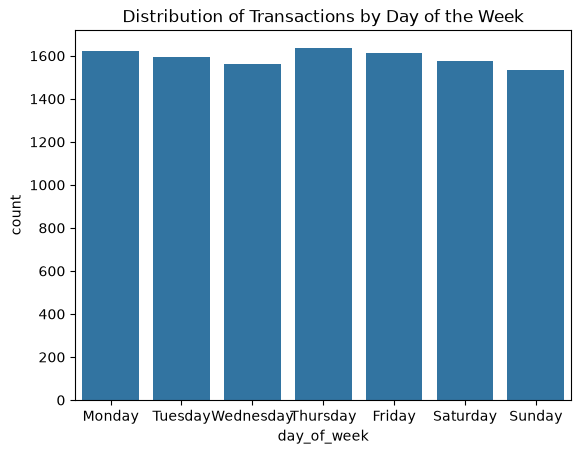

In [109]:
# How are transactions distributed across the days of the week?

sns.countplot(data=data, x='day_of_week')
plt.title('Distribution of Transactions by Day of the Week')
plt.show();

Transaction activity is relatively consistent across all days of the week, with only minor variations in the number of transactions. 

Thursday recorded the highest transaction volume, while Sunday had the lowest. 

Overall, there is no strong day-of-week effect, suggesting that transactions occur fairly uniformly throughout the week.

Categorical Features by Fraud Status

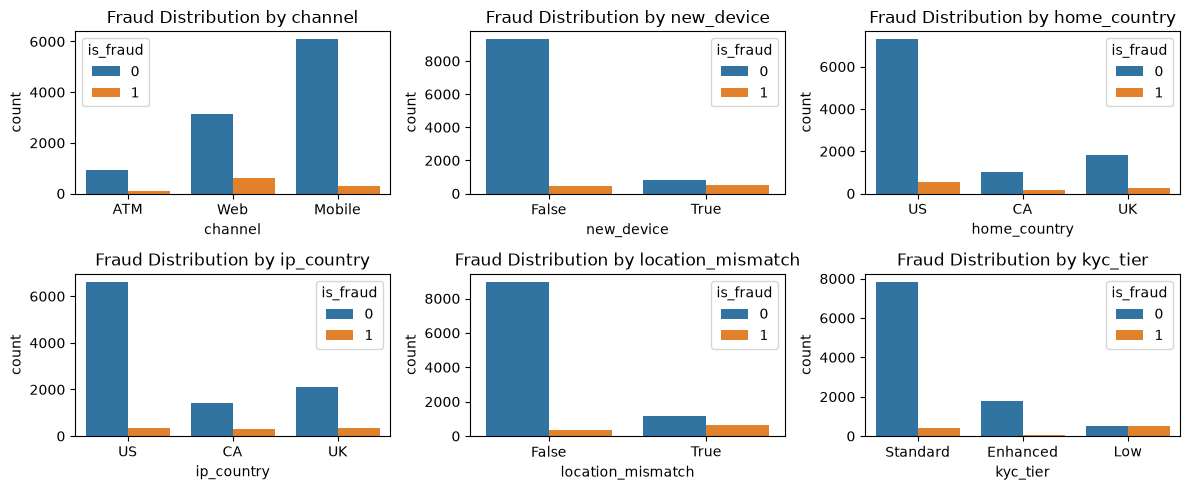

In [110]:
# How are legitimate and fraudulent transactions distributed across categorical features?

categorical_cols = ['channel', 'new_device','home_country','ip_country', 'location_mismatch','kyc_tier']

fig, ax = plt.subplots(2, 3, figsize=(12,5))
ax = ax.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=data, x=col, hue='is_fraud', ax=ax[i])
    ax[i].set_title(f'Fraud Distribution by {col}')

plt.tight_layout()
plt.show()

The countplots show that transaction volume is unevenly distributed across categories.

Mobile is the most frequently used payment channel, most transactions occur on previously recognized devices, and the United States accounts for the largest share of transactions by both home country and IP country. 

Most transactions do not contain a location mismatch, while the Standard KYC tier represents the largest verification group. 

These counts describe the composition of the dataset but do not, by themselves, indicate which categories carry the greatest fraud risk.

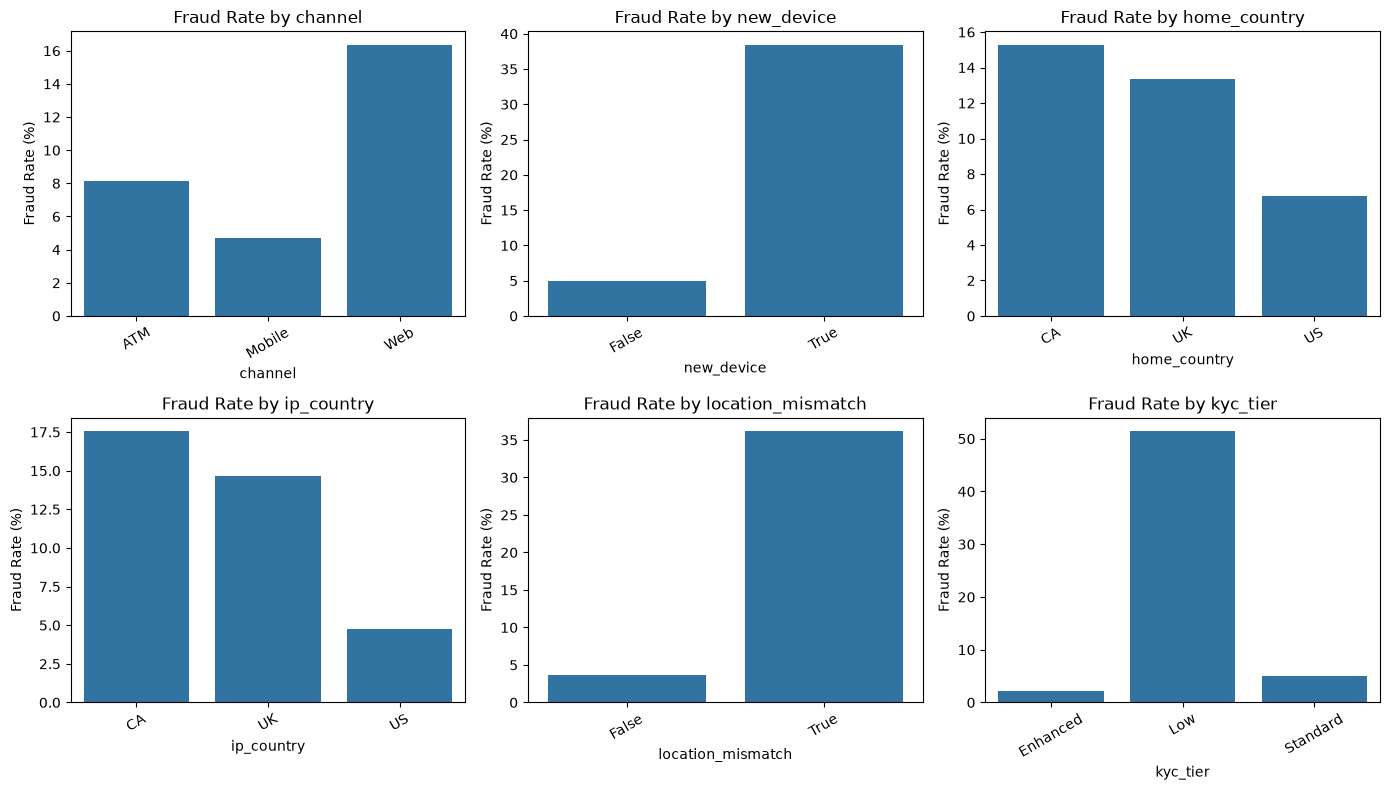

In [111]:
# What percentage of transactions in this category are fraudulent?

categorical_cols = [
    'channel',
    'new_device',
    'home_country',
    'ip_country',
    'location_mismatch',
    'kyc_tier'
]

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax = ax.flatten()

for i, col in enumerate(categorical_cols):

    fraud_rate = (
        data.groupby(col)['is_fraud']
        .mean()
        .mul(100)
        .reset_index()
    )

    sns.barplot(
        data=fraud_rate,
        x=col,
        y='is_fraud',
        ax=ax[i]
    )

    ax[i].set_title(f'Fraud Rate by {col}')
    ax[i].set_ylabel('Fraud Rate (%)')
    ax[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Fraud rates vary considerably across the categorical features. Web transactions have the highest fraud rate among the main payment channels, while transactions initiated from new devices show a substantially higher fraud rate than those from recognized devices. 

Location-mismatched transactions also record a much higher fraud rate than transactions without a mismatch. 

The Low KYC tier has the highest fraud rate by a wide margin, whereas Enhanced and Standard KYC tiers have much lower rates. 

Canada and the United Kingdom show higher fraud rates than the United States across both home-country and IP-country comparisons.

These findings suggest that new-device usage, location mismatch, low KYC verification, payment channel, and geographic information may be useful fraud indicators.

Unknown categories were retained in the analysis. However, the Home Country and Channel Unknown groups contained relatively few transactions, so their fraud rates were interpreted cautiously.

In [112]:
data.columns

Index(['timestamp', 'home_country', 'source_currency', 'dest_currency',
       'channel', 'amount_src', 'amount_usd', 'fee',
       'exchange_rate_src_to_dest', 'new_device', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'year', 'month', 'day_of_month', 'day_of_week', 'hour', 'is_weekend',
       'ip_address_missing'],
      dtype='str')

Numerical Features by Fraud Status

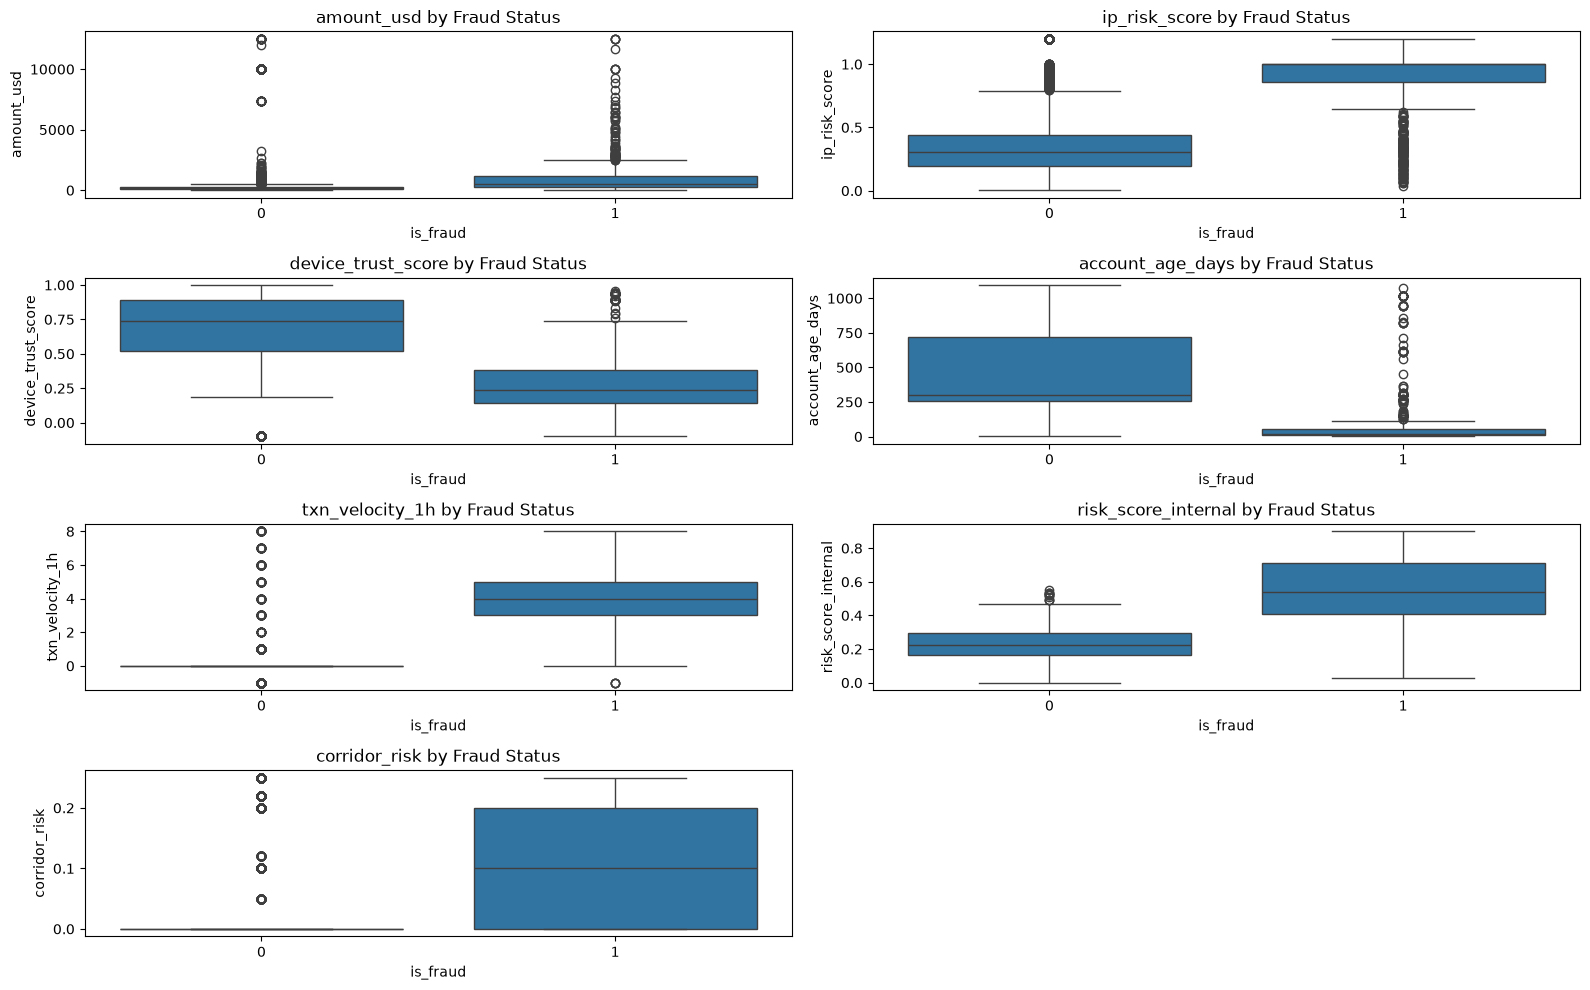

In [113]:
# How do legitimate and fraudulent transactions differ?

numerical_cols = [
    'amount_usd',
    'ip_risk_score',
    'device_trust_score',
    'account_age_days',
    'txn_velocity_1h',
    'risk_score_internal',
    'corridor_risk'
]

fig, ax = plt.subplots(4,2, figsize=(16,10))
ax = ax.flatten()
fig.delaxes(ax[-1])

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=data, x='is_fraud', y=col, ax=ax[i])
    ax[i].set_title(f'{col} by Fraud Status')

plt.tight_layout()
plt.show()

The boxplots show clear differences between legitimate and fraudulent transactions across several numerical features. 

Fraudulent transactions generally involve higher amount_usd, substantially higher ip_risk_score and risk_score_internal, and higher one-hour transaction velocity. They are also associated with lower device_trust_score, much newer accounts, and higher corridor_risk.

Among these variables, IP risk score, device trust score, account age, transaction velocity, internal risk score, and corridor risk show the clearest separation between the two fraud classes.

Transaction amount also tends to be higher for fraud, although both groups contain several extreme values.

Overall, these patterns suggest that fraudulent transactions are more likely to involve risky IP activity, less trusted devices, newer accounts, rapid transaction behaviour, and higher internal or corridor risk.

Correlation Matrix of Numerical Features

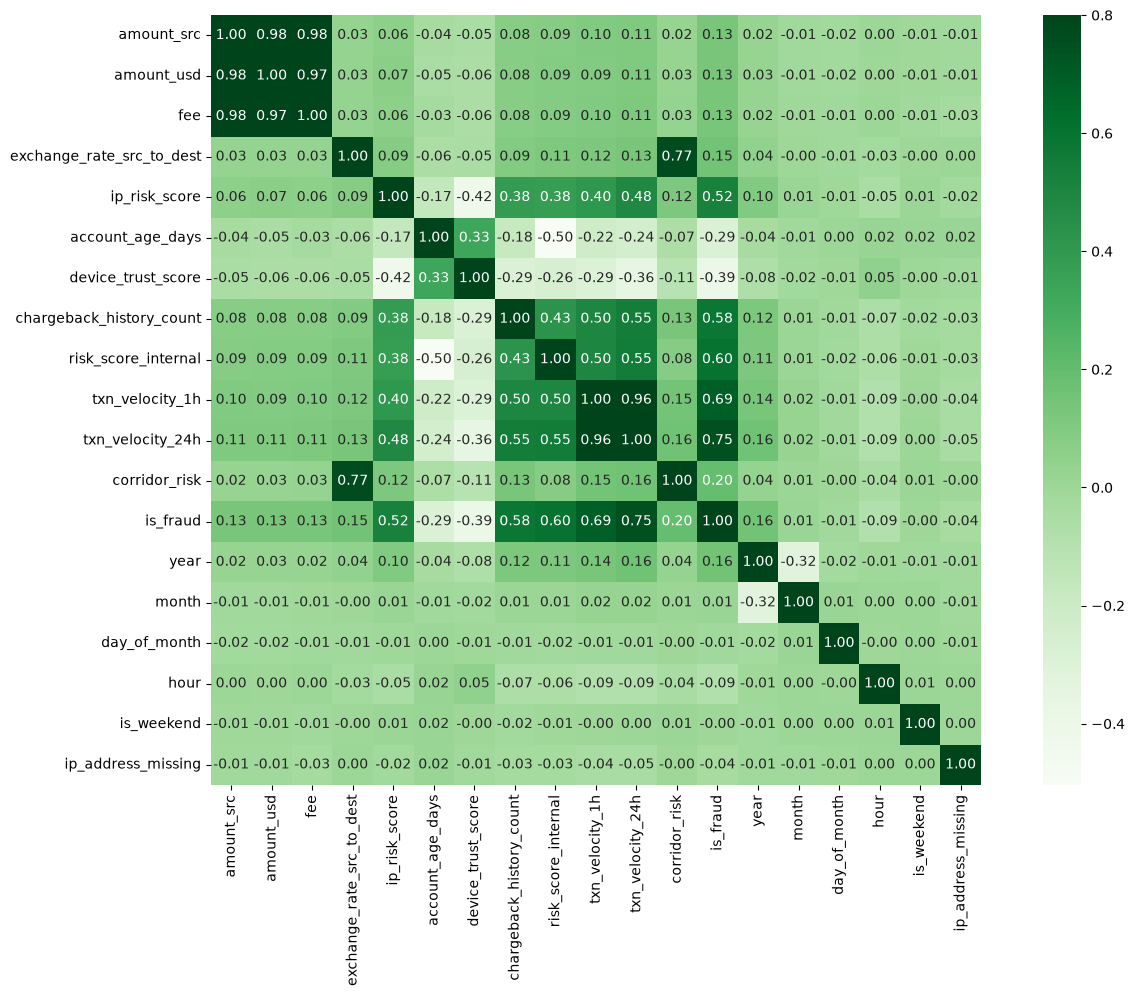

In [114]:
# Which numerical features are most strongly associated with fraudulent transactions?

a= data.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(16, 10))
sns.heatmap(a, vmax= .8,square= True, annot= True, fmt='.2f', cmap='Greens');

The correlation heatmap shows that transaction velocity within 24 hours (txn_velocity_24h) has the strongest positive correlation with fraud (r ≈ 0.75), followed by transaction velocity within 1 hour (txn_velocity_1h) (r ≈ 0.69), internal risk score (risk_score_internal) (r ≈ 0.60), chargeback history count (r ≈ 0.58), and IP risk score (ip_risk_score) (r ≈ 0.52).

These features exhibit the strongest linear relationships with fraudulent transactions and may be important predictors during model development.

In contrast, device trust score (r ≈ -0.39) and account age (r ≈ -0.28) are negatively correlated with fraud, suggesting that transactions from trusted devices and older accounts are less likely to be fraudulent. Most calendar-related variables (year, month, day, hour, and weekend) show little or no correlation with fraud, indicating limited linear association.

Data Pre_Processing

In [115]:
data=data.sort_values('timestamp', ascending = False)
data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day_of_month,day_of_week,hour,is_weekend,ip_address_missing
9912,2025-12-16 00:13:41.468549+00:00,US,USD,PHP,Mobile,175.82,175.82,3.00,58.823529,False,CA,True,0.347,Enhanced,367,0.939,0,0.176,0,0,0.10,0,2025.0,12.0,16.0,Tuesday,0.0,0,0
9761,2025-12-11 19:01:54.468549+00:00,US,USD,USD,Web,1044.46,1044.46,16.83,1.000000,False,UK,True,0.407,Standard,1016,0.944,0,0.247,0,0,0.00,0,2025.0,12.0,11.0,Thursday,19.0,0,0
11199,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,Web,1214.16,1214.16,19.34,1111.111111,True,US,False,1.000,Low,58,0.187,0,0.646,4,6,0.25,1,2025.0,11.0,29.0,Saturday,20.0,1,0
8874,2025-11-29 06:03:37.468549+00:00,US,USD,MXN,Mobile,429.26,429.26,7.64,17.241379,True,US,False,0.315,Standard,263,0.372,0,0.223,4,4,0.20,0,2025.0,11.0,29.0,Saturday,6.0,1,0
9644,2025-11-28 03:01:57.468549+00:00,US,USD,CNY,Mobile,335.76,335.76,6.67,7.142857,False,US,False,0.246,Enhanced,367,0.939,0,0.176,0,0,0.00,0,2025.0,11.0,28.0,Friday,3.0,0,0


In [116]:
data.isnull().sum()

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
year                         0
month                        0
day_of_month                 0
day_of_week                  0
hour                         0
is_weekend                   0
ip_address_missing           0
dtype: int64

In [117]:
X = data.drop(['is_fraud','timestamp'], axis=1)
y = data['is_fraud']

The original timestamp column and the target variable, is_fraud, were excluded from the feature set before model training. The timestamp column was removed because its useful temporal information had already been captured in the derived time-based features.

In [118]:
X.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,year,month,day_of_month,day_of_week,hour,is_weekend,ip_address_missing
9912,US,USD,PHP,Mobile,175.82,175.82,3.00,58.823529,False,CA,True,0.347,Enhanced,367,0.939,0,0.176,0,0,0.10,2025.0,12.0,16.0,Tuesday,0.0,0,0
9761,US,USD,USD,Web,1044.46,1044.46,16.83,1.000000,False,UK,True,0.407,Standard,1016,0.944,0,0.247,0,0,0.00,2025.0,12.0,11.0,Thursday,19.0,0,0
11199,US,USD,NGN,Web,1214.16,1214.16,19.34,1111.111111,True,US,False,1.000,Low,58,0.187,0,0.646,4,6,0.25,2025.0,11.0,29.0,Saturday,20.0,1,0
8874,US,USD,MXN,Mobile,429.26,429.26,7.64,17.241379,True,US,False,0.315,Standard,263,0.372,0,0.223,4,4,0.20,2025.0,11.0,29.0,Saturday,6.0,1,0
9644,US,USD,CNY,Mobile,335.76,335.76,6.67,7.142857,False,US,False,0.246,Enhanced,367,0.939,0,0.176,0,0,0.00,2025.0,11.0,28.0,Friday,3.0,0,0


In [119]:
y.head()

9912     0
9761     0
11199    1
8874     0
9644     0
Name: is_fraud, dtype: int64

In [120]:
X.shape, y.shape

((11140, 27), (11140,))

Data Splitting

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [123]:
X_train.shape, X_test.shape

((8912, 27), (2228, 27))

In [124]:
y_train.shape, y_test.shape

((8912,), (2228,))

In [125]:
y_train.value_counts(normalize=True) * 100

is_fraud
0    91.090664
1     8.909336
Name: proportion, dtype: float64

In [126]:
y_test.value_counts(normalize=True) * 100

is_fraud
0    91.068223
1     8.931777
Name: proportion, dtype: float64

The dataset was split into 80% training and 20% testing sets using stratified sampling. 

This preserved the original class distribution, with both subsets containing approximately 91.1% legitimate transactions and 8.9% fraudulent transactions, ensuring representative data for model training and evaluation.

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [128]:
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'bool']).columns

numerical_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns

In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [130]:
categorical_cols

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier',
       'day_of_week'],
      dtype='str')

In [131]:
numerical_cols

Index(['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'ip_risk_score', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'year', 'month', 'day_of_month',
       'hour', 'is_weekend', 'ip_address_missing'],
      dtype='str')

In [132]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Handling Class Imbalance

In [133]:
y_train.value_counts()

is_fraud
0    8118
1     794
Name: count, dtype: int64

In [134]:
y_train.value_counts(normalize=True) * 100

is_fraud
0    91.090664
1     8.909336
Name: proportion, dtype: float64

The raw dataset contained 8.75% fraudulent transactions. Following duplicate removal and data cleaning, fraud represented approximately 8.9% of the modelling dataset. Stratified splitting preserved this distribution in the training and testing sets.

In [135]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count
scale_pos_weight

np.float64(10.224181360201511)

The calculated scale_pos_weight value is 10.22, meaning the majority class is about ten times larger than the minority class. 

Therefore, XGBoost will assign approximately 10.22 times more weight to fraud cases than legitimate cases during training. 

This helps the model pay more attention to fraudulent transactions and can improve recall, although precision must still be monitored to avoid excessive false positives.

#### SMOTE-Based Model Experiment

In [136]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [137]:

smote_log_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [138]:
smote_log_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [139]:
smote_log_pred = smote_log_model.predict(X_test)
smote_log_prob = smote_log_model.predict_proba(X_test)[:, 1]

In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Accuracy:", accuracy_score(y_test, smote_log_pred))
print("Precision:", precision_score(y_test, smote_log_pred))
print("Recall:", recall_score(y_test, smote_log_pred))
print("F1-score:", f1_score(y_test, smote_log_pred))
print("ROC-AUC:", roc_auc_score(y_test, smote_log_prob))
print("PR-AUC:", average_precision_score(y_test, smote_log_prob))

Accuracy: 0.9452423698384201
Precision: 0.6584362139917695
Recall: 0.8040201005025126
F1-score: 0.7239819004524887
ROC-AUC: 0.9365432386179293
PR-AUC: 0.8595648368086249


The SMOTE-based Logistic Regression model achieved 94.52% accuracy, 65.84% precision, 80.40% recall, and an F1-score of 72.40%. 

The model detected most fraudulent transactions, but its lower precision indicates that it also generated a noticeable number of false fraud alerts.

#### Training Class-Weighted Baseline Models

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Logistic Regression

In [142]:
# Train Logistic Regression

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

In [143]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [144]:
# Predict on the test set

y_pred_log = log_model.predict(X_test)

In [145]:
# Logistic Regression evaluation
log_accuracy = accuracy_score(y_test, y_pred_log)
log_matrix = confusion_matrix(y_test, y_pred_log)

Logistic Regression Accuracy: 0.949281867145422
              precision    recall  f1-score   support

       Legit       0.98      0.96      0.97      2029
       Fraud       0.68      0.81      0.74       199

    accuracy                           0.95      2228
   macro avg       0.83      0.89      0.86      2228
weighted avg       0.95      0.95      0.95      2228



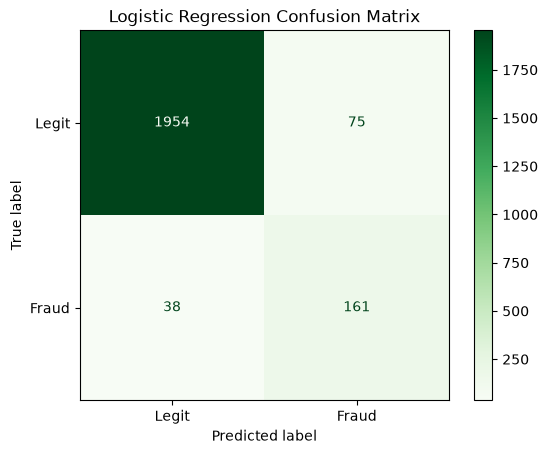

In [146]:
print("Logistic Regression Accuracy:", log_accuracy)
print(classification_report(y_test, y_pred_log, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay( confusion_matrix=log_matrix, display_labels=['Legit', 'Fraud']).plot(cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Logistic Regression correctly identified 161 of the 199 fraudulent transactions, giving a recall of approximately 81%.

However, it also produced 75 false-positive fraud alerts, which reduced precision to approximately 68%. 

This shows that the model detected most fraudulent transactions but also incorrectly flagged a noticeable number of legitimate transactions as fraud.

Random Forest Model

In [147]:
from sklearn.ensemble import RandomForestClassifier

In [148]:
# Train Random Forest Model

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

In [149]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [150]:
# Predict on the test set

y_pred_rf = rf_model.predict(X_test)

In [151]:
# Evaluate performance

accuracy = accuracy_score(y_test, y_pred_rf)
matrix = confusion_matrix(y_test, y_pred_rf)

Random Forest Accuracy: 0.9789048473967684
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99      2029
       Fraud       0.97      0.78      0.87       199

    accuracy                           0.98      2228
   macro avg       0.98      0.89      0.93      2228
weighted avg       0.98      0.98      0.98      2228



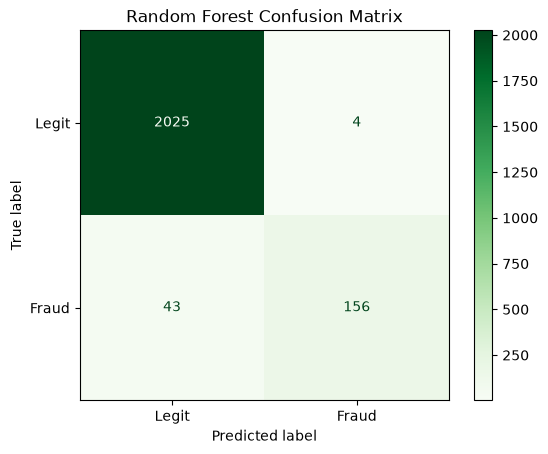

In [152]:
print("Random Forest Accuracy:", accuracy)
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay( confusion_matrix=matrix, display_labels=['Legit', 'Fraud']).plot(cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

The Random Forest model correctly classified 2,025 legitimate transactions and detected 156 of the 199 fraudulent transactions. 

It produced only 4 false-positive alerts, resulting in a fraud precision of approximately 97.8%.

However, it missed 43 fraud cases, giving a recall of approximately 78.0%.

Overall, the model was highly effective at minimizing false fraud alerts while still detecting most fraudulent transactions.

### Training Additional Tree-Based Models

LightGBM Model

In [153]:
from lightgbm import LGBMClassifier

In [154]:
# Train LightGBM Model

lgbm_model = Pipeline(steps=[ 
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
         random_state=42, 
         class_weight='balanced' 
         ))
         ])

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 794, number of negative: 8118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1963
[LightGBM] [Info] Number of data points in the train set: 8912, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

LightGBM Accuracy: 0.9775583482944344
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99      2029
       Fraud       0.96      0.78      0.86       199

    accuracy                           0.98      2228
   macro avg       0.97      0.89      0.92      2228
weighted avg       0.98      0.98      0.98      2228



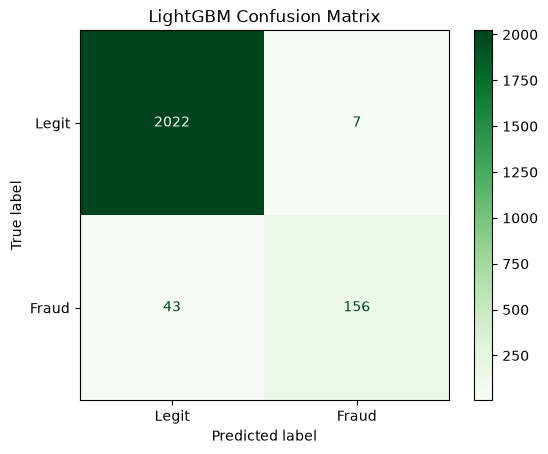

In [155]:
# Predict on the test set

y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate performance

lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_matrix = confusion_matrix(y_test, y_pred_lgbm)

print("LightGBM Accuracy:", lgbm_accuracy)

print( classification_report( y_test, y_pred_lgbm, target_names=['Legit', 'Fraud']))

ConfusionMatrixDisplay( confusion_matrix=lgbm_matrix, display_labels=['Legit', 'Fraud']).plot(cmap='Greens')

plt.title('LightGBM Confusion Matrix')
plt.show()

LightGBM correctly detected 156 of the 199 fraudulent transactions, giving a recall of approximately 78.0%. 

It generated only 7 false-positive alerts, showing strong precision and good control of false alarms.

However, it still missed 43 fraud cases, indicating that further recall improvement may be needed

 Decision Tree Model

In [156]:
from sklearn.tree import DecisionTreeClassifier

In [157]:
# Train Decision Tree Model

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

Decision Tree Accuracy: 0.9600538599640933
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98      2029
       Fraud       0.77      0.78      0.78       199

    accuracy                           0.96      2228
   macro avg       0.88      0.88      0.88      2228
weighted avg       0.96      0.96      0.96      2228



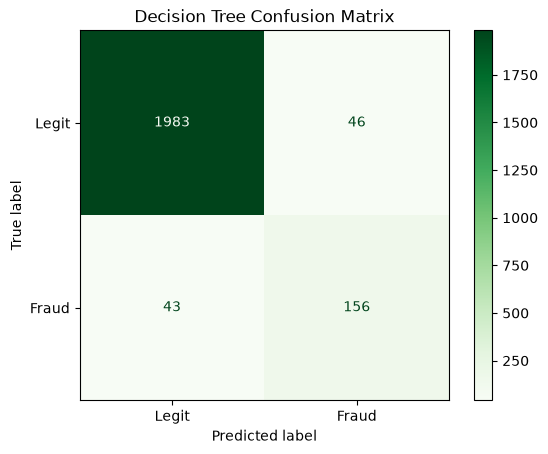

In [158]:
# Predict on the test set

y_pred_dt= dt_model.predict(X_test)

# Evaluate performance

accuracy = accuracy_score(y_test, y_pred_dt)
matrix = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy)
print(classification_report(y_test, y_pred_dt, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay( confusion_matrix=matrix, display_labels=['Legit', 'Fraud']).plot(cmap='Greens')

plt.title('Decision Tree Confusion Matrix')
plt.show()

The Decision Tree correctly detected 156 of the 199 fraudulent transactions, giving a recall of approximately 78.0%.

 However, it also produced 46 false-positive fraud alerts, resulting in lower precision than the ensemble models. 
 
 This shows that although it identified many fraud cases, it was less effective at minimizing false alarms.

XGBoost Model

In [159]:
from xgboost import XGBClassifier

In [160]:
# Train XGBoost Model

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['home_country','source_currency','dest_currency',...,'hour','is_weekend', 'ip_address_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

XGBoost Accuracy: 0.9789048473967684
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98      2029
       Fraud       0.77      0.78      0.78       199

    accuracy                           0.96      2228
   macro avg       0.88      0.88      0.88      2228
weighted avg       0.96      0.96      0.96      2228



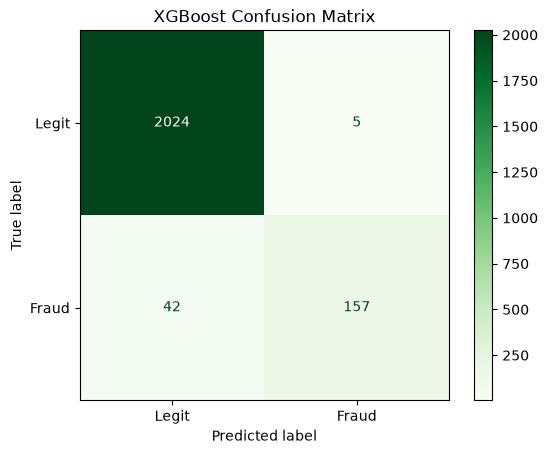

In [161]:
# Predict on the test set

y_pred_xgb= xgb_model.predict(X_test)

# Evaluate performance

accuracy = accuracy_score(y_test, y_pred_xgb)
matrix = confusion_matrix(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy)
print(classification_report(y_test, y_pred_dt, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay( confusion_matrix=matrix, display_labels=['Legit', 'Fraud']).plot(cmap='Greens')

plt.title('XGBoost Confusion Matrix')
plt.show()

XGBoost correctly identified 157 fraudulent transactions and missed 42 fraud cases, giving a recall of approximately 78.9%. 

It also produced only 5 false positives, resulting in very high precision. Overall, the model showed a strong balance between detecting fraud and minimizing false alerts.

#### ROC Curve Comparison Across Models

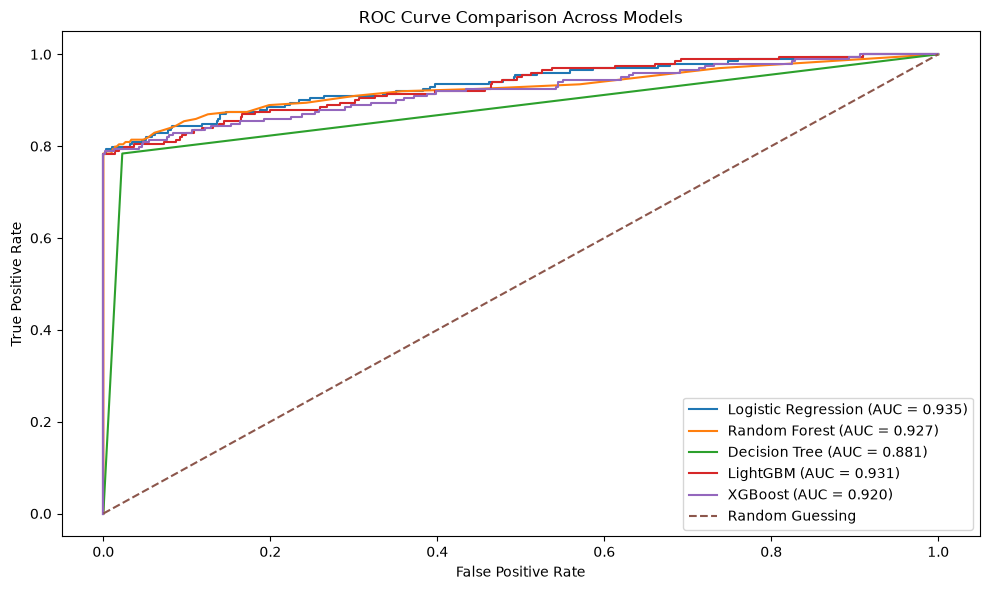

In [162]:
# ROC Curve Comparison Across Models

from sklearn.metrics import roc_curve, roc_auc_score


models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'LightGBM': lgbm_model,
    'XGBoost': xgb_model
}

plt.figure(figsize=(10, 6))

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

ROC-AUC Comparison Findings

All five models performed better than random guessing, as their ROC curves remained well above the diagonal reference line. 

Logistic Regression achieved the highest ROC-AUC score of 0.935, followed closely by LightGBM at 0.931 and Random Forest at 0.927. 

XGBoost recorded an AUC of 0.920, while Decision Tree had the lowest score at 0.881.

Overall Model Performance Comparison


In [163]:
# Predicted fraud probabilities

y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_smote_log = smote_log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [164]:
results = {
    'Logistic Regression': {},
    'SMOTE Logistic Regression': {},
    'Random Forest': {},
    'Decision Tree': {},
    'LightGBM': {},
    'XGBoost': {}
}

In [165]:
results['Logistic Regression'].update({
    'accuracy': accuracy_score(y_test, y_pred_log),
    'precision': precision_score(y_test, y_pred_log),
    'recall': recall_score(y_test, y_pred_log),
    'f1_score': f1_score(y_test, y_pred_log)
})

results['SMOTE Logistic Regression'].update({
    'accuracy': accuracy_score(y_test, smote_log_pred),
    'precision': precision_score(y_test, smote_log_pred),
    'recall': recall_score(y_test, smote_log_pred),
    'f1_score': f1_score(y_test, smote_log_pred)
})

results['Random Forest'].update({
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1_score': f1_score(y_test, y_pred_rf)
})

results['Decision Tree'].update({
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt),
    'recall': recall_score(y_test, y_pred_dt),
    'f1_score': f1_score(y_test, y_pred_dt)
})

results['LightGBM'].update({
    'accuracy': accuracy_score(y_test, y_pred_lgbm),
    'precision': precision_score(y_test, y_pred_lgbm),
    'recall': recall_score(y_test, y_pred_lgbm),
    'f1_score': f1_score(y_test, y_pred_lgbm)
})

results['XGBoost'].update({
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1_score': f1_score(y_test, y_pred_xgb)
})

In [166]:
results['Logistic Regression']['roc_auc'] = roc_auc_score(y_test, y_prob_log)
results['Logistic Regression']['pr_auc'] = average_precision_score(y_test, y_prob_log)

results['SMOTE Logistic Regression']['roc_auc'] = roc_auc_score(
    y_test, smote_log_prob
)
results['SMOTE Logistic Regression']['pr_auc'] = average_precision_score(
    y_test, smote_log_prob
)

results['Random Forest']['roc_auc'] = roc_auc_score(y_test, y_prob_rf)
results['Random Forest']['pr_auc'] = average_precision_score(y_test, y_prob_rf)

results['Decision Tree']['roc_auc'] = roc_auc_score(y_test, y_prob_dt)
results['Decision Tree']['pr_auc'] = average_precision_score(y_test, y_prob_dt)

results['LightGBM']['roc_auc'] = roc_auc_score(y_test, y_prob_lgbm)
results['LightGBM']['pr_auc'] = average_precision_score(y_test, y_prob_lgbm)

results['XGBoost']['roc_auc'] = roc_auc_score(y_test, y_prob_xgb)
results['XGBoost']['pr_auc'] = average_precision_score(y_test, y_prob_xgb)

In [167]:
summary_data = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={'index': 'Model'})
    .sort_values(by='f1_score', ascending=False)
)

summary_data

,Model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
5,XGBoost,0.978905,0.969136,0.788945,0.869806,0.920264,0.848124
2,Random Forest,0.978905,0.975000,0.783920,0.869081,0.926510,0.857941
4,LightGBM,0.977558,0.957055,0.783920,0.861878,0.930617,0.850196
3,Decision Tree,0.960054,0.772277,0.783920,0.778055,0.880624,0.624703
0,Logistic Regression,0.949282,0.682203,0.809045,0.740230,0.934758,0.860101
1,SMOTE Logistic Regression,0.945242,0.658436,0.804020,0.723982,0.936543,0.859565


### Overall Model Performance Comparison

The model comparison shows that XGBoost achieved the highest F1-score and tied with Random Forest for the highest accuracy. 

Random Forest recorded the highest precision, meaning it generated the fewest false fraud alerts. 

Logistic Regression achieved the highest recall, while SMOTE Logistic Regression recorded the highest ROC-AUC. 

LightGBM also performed strongly, whereas Decision Tree produced the weakest overall results. 

Based on the balance of precision, recall, F1-score, and accuracy, XGBoost was selected as the final model.

#### Model Selection and Hyperparameter Tuning Using GridSearchCV

In [168]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [169]:
# Full param_grid with all models

param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)],
        'classifier__C': [0.1, 1, 10]
    },
    {
        'classifier': [DecisionTreeClassifier(class_weight='balanced', random_state=42)],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5]
    },
    {
        'classifier': [RandomForestClassifier(class_weight='balanced', random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    },
    { 
        'classifier': [LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1)],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__num_leaves': [15, 31],
        'classifier__max_depth': [-1, 10, 20],
        'classifier__min_child_samples': [20, 40]
    },
    {   
        'classifier': [XGBClassifier(random_state=42, eval_metric='logloss')],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    }
]

In [170]:
# Run GridSearchCV

grid_search_all = GridSearchCV(
    estimator=model_pipe,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search_all.fit(X_train, y_train)

Fitting 3 folds for each of 89 candidates, totalling 267 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [LogisticRegre...ndom_state=42)], 'classifier__C': [0.1, 1, ...]}, {'classifier': [DecisionTreeC...ndom_state=42)], 'classifier__max_depth': [10, 20, ...], 'classifier__min_samples_split': [2, 5]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``

In [171]:
# Print best model and best parameters

print("Best Model:", grid_search_all.best_estimator_.named_steps['classifier'])
print("Best Parameters:", grid_search_all.best_params_)
print("Best F1 Score:", grid_search_all.best_score_)

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
Best Parameters: {'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_sto

GridSearchCV compared Random Forest, LightGBM, Decision Tree, Logistic Regression, and XGBoost across 89 model and hyperparameter combinations using three-fold cross-validation. XGBoost achieved the highest mean cross-validation F1 score of approximately 0.894, with learning_rate=0.05, max_depth=3, and n_estimators=100.

              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99      2029
       Fraud       1.00      0.78      0.88       199

    accuracy                           0.98      2228
   macro avg       0.99      0.89      0.93      2228
weighted avg       0.98      0.98      0.98      2228

Test F1 Score: 0.8788732394366198
Test ROC-AUC: 0.941704580071377
Confusion Matrix:
 [[2029    0]
 [  43  156]]


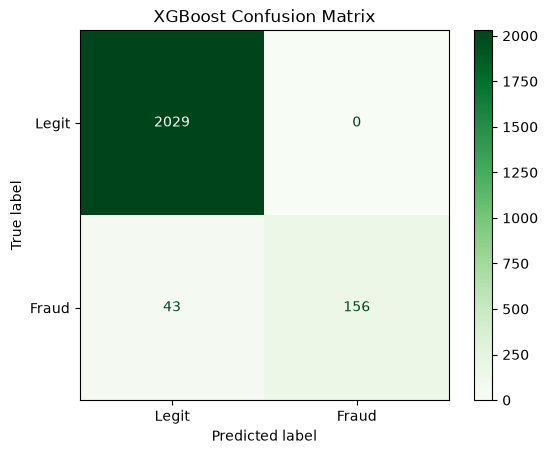

In [172]:
best_model = grid_search_all.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

matrix = confusion_matrix(y_test, y_pred)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Legit', 'Fraud']
))

print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", matrix)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['Legit', 'Fraud']
).plot(cmap='Greens')

plt.title('XGBoost Confusion Matrix')
plt.show()

The tuned XGBoost model achieved an F1 score of 0.879 and a ROC-AUC score of 0.942 on the test data. It correctly identified 156 out of 199 fraudulent transactions and did not incorrectly classify any legitimate transaction as fraud. However, it missed 43 fraudulent transactions, resulting in a fraud recall of 0.78.

Model Explainability with SHAP

In [173]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [174]:
import shap
import pandas as pd

c:\Users\olade\Downloads\DS Internship Program\Novapay_fraudulent\nova-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [175]:
# Extract parts of the best pipeline
best_pipeline = grid_search_all.best_estimator_

preprocessor = best_pipeline.named_steps['preprocessor']
xgb_model = best_pipeline.named_steps['classifier']

# Transform the test data exactly as the model received it
X_test_transformed = preprocessor.transform(X_test)

# Get the transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer(X_test_shap)

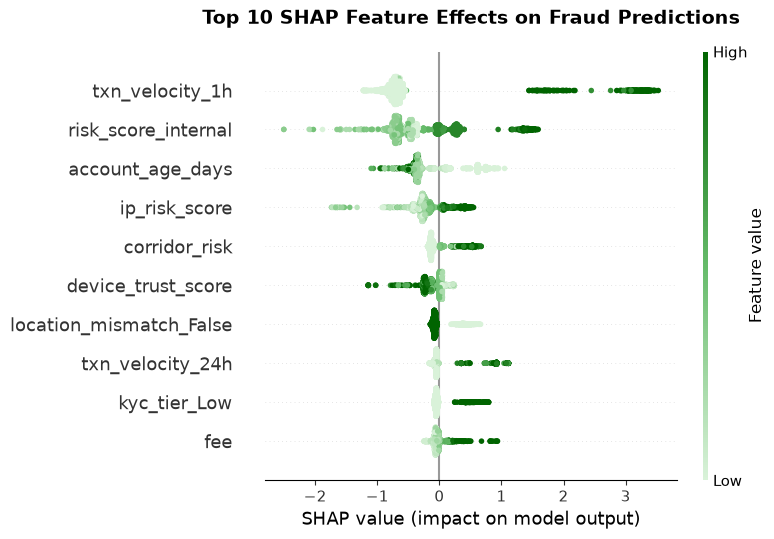

In [176]:
# Top 10 SHAP Feature Effects

import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create green gradient
green_cmap = LinearSegmentedColormap.from_list(
    'custom_green',
    ['#d9f2d9', '#66bb6a', '#006400']
)

shap.summary_plot( shap_values.values, X_test_shap, feature_names=[ name.replace('num__', '').replace('cat__', '') for name in X_test_shap.columns], max_display=10, cmap=green_cmap, show=False
)

plt.title( 'Top 10 SHAP Feature Effects on Fraud Predictions', fontsize=14, fontweight='bold', pad=20 )

plt.tight_layout()
plt.show()

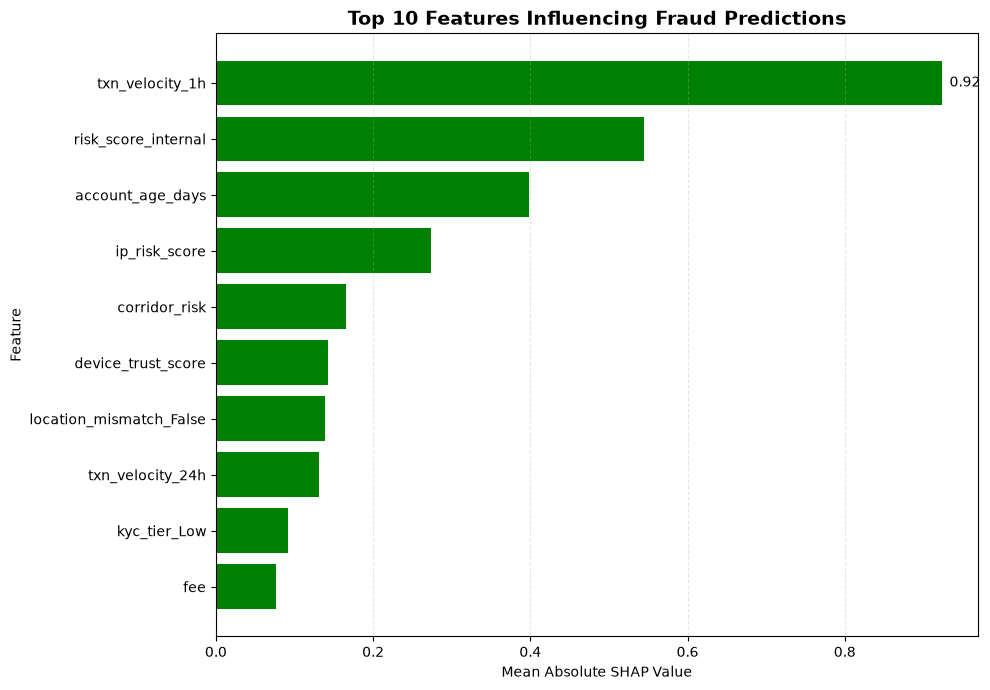

In [177]:
# Top 10 SHAP Feature Importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({'Feature': X_test_shap.columns, 'Importance': np.abs(shap_values.values).mean(axis=0)})

# Select the top 10
top_10_shap = ( shap_importance .sort_values('Importance', ascending=False) .head(10) .sort_values('Importance', ascending=True))

# Clean feature names
top_10_shap['Feature'] = (top_10_shap['Feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False))

# Plot
plt.figure(figsize=(10, 7))

bars = plt.barh( top_10_shap['Feature'], top_10_shap['Importance'], color='green')

# Add values beside bars
for bar in bars: width = bar.get_width()

plt.text( width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.2f}', va='center', fontsize=10)

plt.title( 'Top 10 Features Influencing Fraud Predictions', fontsize=14, fontweight='bold')

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The SHAP analysis shows that txn_velocity_1h is the most influential feature in the model, followed by risk_score_internal, account_age_days, ip_risk_score, and corridor_risk.

High transaction activity within one hour and high internal risk scores strongly increase the likelihood that a transaction will be classified as fraud. 

Higher IP risk and corridor risk also push predictions toward fraud. In contrast, older accounts and higher device trust scores generally reduce the likelihood of a fraud prediction. 

Overall, the model relies mainly on transaction behaviour, risk indicators, account history, and device-related information when identifying fraudulent transactions.

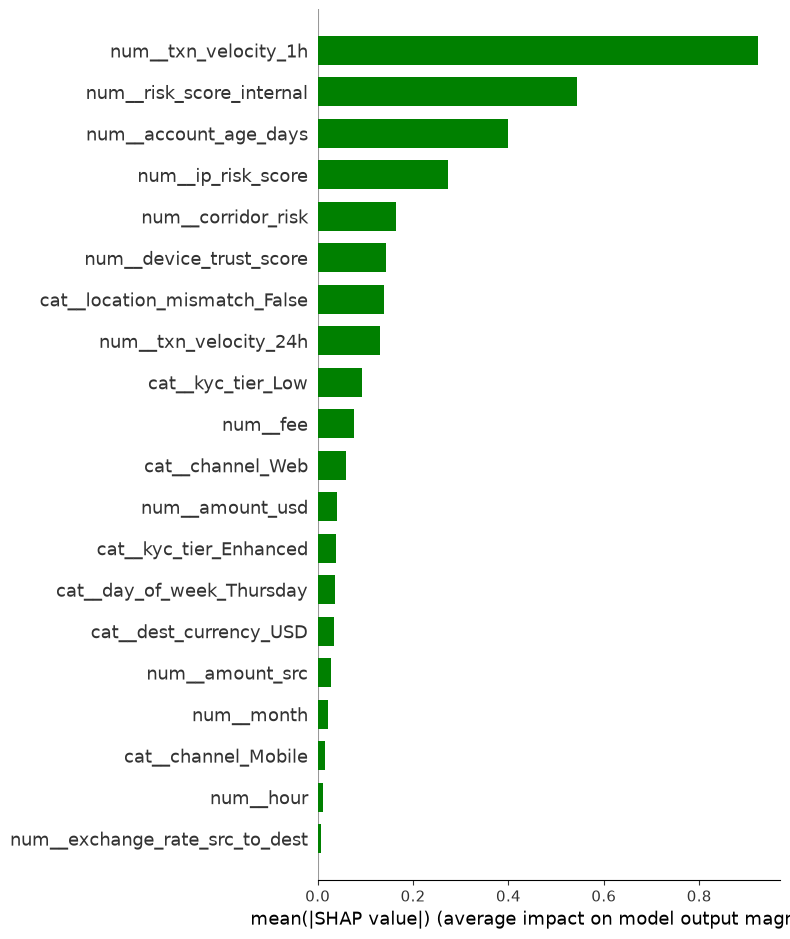

In [178]:
# Overall feature importance plot

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type='bar', color ='Green'
)

Model Deployment with FastAPI and Docker

In [179]:
# Save the best model

import joblib

novapay_xgboost_pipeline = grid_search_all.best_estimator_

joblib.dump(
    novapay_xgboost_pipeline, "model/novapay_xgboost_pipeline.pkl"
)

['model/novapay_xgboost_pipeline.pkl']

In [181]:
# Test the saved pipeline

loaded_pipeline = joblib.load(
    "model/novapay_xgboost_pipeline.pkl"
)

sample_transaction = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_transaction)[0]
fraud_probability = loaded_pipeline.predict_proba(sample_transaction)[0, 1]

print("Prediction:", "Fraud" if prediction == 1 else "Legitimate")
print("Fraud probability:", round(fraud_probability, 4))

Prediction: Legitimate
Fraud probability: 0.0084


In [182]:
# Test a Known Fraud Transaction

fraud_predictions = loaded_pipeline.predict(X_test)

correct_fraud_indices = X_test.index[
    (y_test == 1) & (fraud_predictions == 1)
]

known_fraud = X_test.loc[[correct_fraud_indices[0]]]

prediction = loaded_pipeline.predict(known_fraud)[0]
fraud_probability = loaded_pipeline.predict_proba(known_fraud)[0, 1]

print("Actual: Fraud")
print("Prediction:", "Fraud" if prediction == 1 else "Legitimate")
print("Fraud probability:", round(fraud_probability, 4))

Actual: Fraud
Prediction: Fraud
Fraud probability: 0.9938


The saved XGBoost pipeline correctly identified the selected fraudulent transaction and assigned it a fraud probability of 99.38%. This confirms that the saved pipeline can successfully preprocess new transaction data and generate both class predictions and fraud probabilities.